In [1]:
import pandas as pd
import re
from difflib import get_close_matches
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
import numpy as np
from pathlib import Path
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from scipy.stats import chi2_contingency
from pathlib import Path
from scipy.stats import t as tdist
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.linear_model import RidgeCV, ElasticNetCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, f1_score,calinski_harabasz_score,davies_bouldin_score
from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from statsmodels.stats.multitest import multipletests
from joblib import Parallel, delayed
import io, base64
from scipy.stats import kruskal
from IPython.display import HTML, display



# Loading the genetic dataset

In [2]:
# Read the genetic data
genetic_data = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\GeneMarkers-95 varieties 1.csv")

genetic_data.info
genetic_data.head(10)

,taglo_id,ATLANTIC_124776,ESCORT_159228,ARGOS_120931,ALTURAS_329540,ELMUNDO_835520,NADINE_241950,VIOLETQUEEN_3345402,DEODARA_513721,MEMPHIS_2279529,...,DIAMANT_153502,INNOVATOR_234757,TRIPLE7_3347283,SPUNTA_283648,ANTI_118190,CARRERA_142554,FORTUS_3279866,SMART_1883446,SALINERO_253609,FABULA_171173
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,13,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,17,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,21,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,22,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,39,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,48,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,49,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,54,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


# Checking the missing values

In [3]:
genetic_data.isnull().sum()

taglo_id           0
ATLANTIC_124776    0
ESCORT_159228      0
ARGOS_120931       0
ALTURAS_329540     0
                  ..
CARRERA_142554     0
FORTUS_3279866     0
SMART_1883446      0
SALINERO_253609    0
FABULA_171173      0
Length: 95, dtype: int64

In [4]:
# Clean column names
genetic_columns_clean = [c.strip().upper().replace(" ", "").replace(".", "") for c in genetic_data.columns]

# Assign cleaned names back to DataFrame
genetic_data.columns = genetic_columns_clean
print(genetic_data.columns)

Index(['TAGLO_ID', 'ATLANTIC_124776', 'ESCORT_159228', 'ARGOS_120931',
       'ALTURAS_329540', 'ELMUNDO_835520', 'NADINE_241950',
       'VIOLETQUEEN_3345402', 'DEODARA_513721', 'MEMPHIS_2279529',
       'AGRIA_125336', 'PAYETTERUSSET_4617676', 'IVORYRUSSET_1360551',
       'SABABA_4959615', 'CECILE_147140', 'FRISIA_163592', 'CARDYMA_3345873',
       'RICKEYRUSSET_4640884', 'ANIVIA_4446779', 'AVARNA_1630052',
       'DONALD_158741', 'JAERLA_231308', 'ARIZONA_3056017',
       'SARPOMIRA_1629377', 'MARILYN_1632173', 'DESIREE_139717',
       'MUSE_6159099', 'ADORA_123802', 'TAURUS_1883495', 'BERBER_121293',
       'RANGERRUSSET_265488', 'BINTJE_126680', 'FENWAYRED_4055844',
       'KONDOR_248484', 'SAGITTA_1459411', 'CLEARWATERR_2721777',
       'NICOLA_248062', 'TETONRUSSET_3029162', 'FESTIEN_172619',
       'HANSA_180216', 'PEEWEERUSSET_3347291', 'PRINCEOFORANGE_416115',
       'SUPERIOR_1477892', 'VANGOGH_294181', 'CHALLENGER_1883438',
       'JENNIFER_3221728', 'PARELLA_2983716', 'CH

# loading theflavor and aroma dataset which already derived.

In [5]:
merged_flavor_aroma= pd.read_csv(r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\aroma_plus_predicted_flavors_94.csv')
merged_flavor_aroma
merged_flavor_aroma.columns

Index(['Variety', '1-Nonanol (Floral, waxy)',
       '2,3-Butanedione (Butter, creamy, sweet)',
       'Benzaldehyde (Almond, cherry, fruity)',
       'Butanal, 3-methyl- (Fruity, malty, chocolate)',
       'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)',
       'Decanal (Citrus, floral)',
       'Dimethyl trisulfide (Garlic, onion, sulfurous)',
       'Furfural (Sweet, almond, caramel)', 'Hexanal (Green, grassy)',
       'Hexanoic acid (Fatty, cheesy, sweaty)',
       'Methional (Cooked potato, sulfurous)', 'Octanal (Citrus, fruity)',
       'Pentanal (Green, fatty, pungent)', 'Metallic Flavour__pred',
       'Bitter Flavour__pred', 'Earthy Flavour__pred', 'Sour Flavour__pred',
       'Fresh Flavour__pred', 'Sweet Flavour__pred',
       'Root/ Vegetable Flavour__pred', 'Farmyard (grass/hay) flavour__pred',
       'Bitter Aftertaste__pred', 'Sour Aftertaste__pred',
       'Sweet Aftertaste__pred', 'Metallic Flavour__pred_cal',
       'Bitter Flavour__pred_cal', 'Earthy Flavou

# Merge genetic data with aroma_flavor dataset for further analysis

In [6]:
# preparing the data
def to_numeric(df):
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def norm_key(s):
    s = (str(s).upper().replace(".", "").replace(" ", ""))
    s = re.sub(r'\bR\b', '', s)
    s = re.sub(r'RUSSET', '', s)
    return s.split("_")[0]

# Detecting the SNP marker column 
mrk_col = "TAGLO_ID" if "TAGLO_ID" in genetic_data.columns else genetic_data.columns[0]

#  Clean genetics 
G = genetic_data.dropna(subset=[mrk_col]) \
                .drop_duplicates(subset=[mrk_col]) \
                .set_index(mrk_col)

G = to_numeric(G)         # convert to numeric (0/1/2)
gd = G.T                  # varieties × markers
gd.index.name = "Variety_raw"
gd.index = gd.index.map(norm_key)

# Collapse duplicates if multiple rows per variety
gd = gd.groupby(gd.index, observed=True).mean()
gd.columns = ["GEN__" + str(c) for c in gd.columns]
print("Genetic table after reshape:", gd.shape)

# copy of  Aroma + Flavor 
af = merged_flavor_aroma.copy()
assert "Variety" in af.columns, "merged_flavor_aroma must have a 'Variety' column"
af["__key__"] = af["Variety"].map(norm_key)
af = af.set_index("__key__")

#proviiding the  Aroma names 
aroma_names = [
    '1-Nonanol (Floral, waxy)',
    '2,3-Butanedione (Butter, creamy, sweet)',
    'Benzaldehyde (Almond, cherry, fruity)',
    'Butanal, 3-methyl- (Fruity, malty, chocolate)',
    'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)',
    'Decanal (Citrus, floral)',
    'Dimethyl trisulfide (Garlic, onion, sulfurous)',
    'Furfural (Sweet, almond, caramel)',
    'Hexanal (Green, grassy)',
    'Hexanoic acid (Fatty, cheesy, sweaty)',
    'Methional (Cooked potato, sulfurous)',
    'Octanal (Citrus, fruity)',
    'Pentanal (Green, fatty, pungent)',
]

col_str = af.columns.astype(str)

# Keeping only the calibrated flavor predictions
flavor_cols = [c for c in col_str if c.endswith("__pred_cal")]

# Keep only whitelist aroma compounds that exist
aroma_cols = [c for c in aroma_names if c in col_str]

# Clean aroma 
A = to_numeric(af[aroma_cols]).dropna(axis=1, how="all")
A = A.loc[:, A.std(ddof=0).fillna(0) > 0]   # drop constant cols

# Flavors
F = to_numeric(af[flavor_cols])

print(f"# aroma candidates (usable): {A.shape[1]}")
print(f"# predicted flavor cols (cal only): {F.shape[1]}")
print("Sample aroma cols:", list(A.columns[:8]))

# Merge with genetics
gk = gd.copy()
gk.index.name = "Variety"

merged_all = gk.join(pd.concat([A, F], axis=1), how="inner")
print("Merged shape (varieties × [SNPs + aroma + flavor]):", merged_all.shape)


Genetic table after reshape: (94, 262434)
# aroma candidates (usable): 13
# predicted flavor cols (cal only): 11
Sample aroma cols: ['1-Nonanol (Floral, waxy)', '2,3-Butanedione (Butter, creamy, sweet)', 'Benzaldehyde (Almond, cherry, fruity)', 'Butanal, 3-methyl- (Fruity, malty, chocolate)', 'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)', 'Decanal (Citrus, floral)', 'Dimethyl trisulfide (Garlic, onion, sulfurous)', 'Furfural (Sweet, almond, caramel)']
Merged shape (varieties × [SNPs + aroma + flavor]): (94, 262458)


the merged data includes 94 veraities along with 13 aroma and 11 flavor

# ANOVA for genetic data and aroma (beacuse the flavors predicted by aroma)

In [7]:

#  Configurtion
SNP_PREFIX      = "GEN__"
MIN_MAF         = 0.05
MAX_MAF         = 0.95
MIN_GROUP_SIZE  = 5
TOP_K_PER_AROMA = 10      # show only top-K per aroma to keep output small 
N_JOBS          = -1     

#  Prep data 
df = merged_all.copy()
df.index.name = "Variety"

# Columns
snp_cols   = [c for c in df.columns if c.startswith(SNP_PREFIX)]
aroma_cols = [c for c in aroma_names if c in df.columns]
if not aroma_cols:
    raise ValueError("No aroma columns found.")

# Extract arrays
G_full = df[snp_cols].to_numpy(dtype=float)    
A_full = df[aroma_cols].to_numpy(dtype=float)  
varieties = df.index.to_numpy()

n, s = G_full.shape
_, a = A_full.shape

# Pre-filter SNPs (once)
# Drop all-NaN
non_all_nan = ~np.all(np.isnan(G_full), axis=0)

# Drop constant (considering NaNs)
col_min = np.nanmin(G_full, axis=0)
col_max = np.nanmax(G_full, axis=0)
non_const = col_min < col_max

# MAF filter (0/1 or 0/1/2)
xmax = np.nanmax(G_full, axis=0)
den  = np.where(xmax == 2, 2.0, 1.0)  # 2 for dosages, 1 for binary
p    = np.nanmean(G_full, axis=0) / den
maf  = np.minimum(p, 1 - p)
maf_ok = (maf >= MIN_MAF) & (maf <= MAX_MAF)

keep_snp_mask = non_all_nan & non_const & maf_ok
if not np.any(keep_snp_mask):
    raise ValueError("No SNPs left after pre-filtering. Relax filters or check data.")

G = G_full[:, keep_snp_mask]
kept_snp_cols = np.array(snp_cols)[keep_snp_mask]
S = G.shape[1]


#Fast one-way ANOVA 
def fast_anova_F_p(y, g):
    
    # valid where both present
    m = (~np.isnan(y)) & (~np.isnan(g))
    if m.sum() < MIN_GROUP_SIZE * 2:
        return (np.nan, np.nan, False)

    yv = y[m]
    gv = g[m]

    # unique genotypes present
    u = np.unique(gv)
    k = u.size
    if k < 2:
        return (np.nan, np.nan, False)

    # group stats
    ns = []
    means = []
    ss_within = 0.0
    for val in u:
        idx = (gv == val)
        n_g = int(idx.sum())
        if n_g < MIN_GROUP_SIZE:
            return (np.nan, np.nan, False)
        y_g = yv[idx]
        mu  = y_g.mean()
        ns.append(n_g)
        means.append(mu)
        # sum of squares within group
        ss_within += np.sum((y_g - mu) ** 2)

    ns = np.array(ns, dtype=float)
    means = np.array(means, dtype=float)
    N = int(ns.sum())

    # between-group SS
    grand_mean = np.sum(ns * means) / N
    ss_between = np.sum(ns * (means - grand_mean) ** 2)

    df_between = k - 1
    df_within  = N - k
    if df_within <= 0 or df_between <= 0:
        return (np.nan, np.nan, False)

    ms_between = ss_between / df_between
    ms_within  = ss_within  / df_within
    if ms_within <= 0:
        return (np.nan, np.nan, False)

    F = ms_between / ms_within

    # p-value from F-distribution
    # Using scipy here would add overhead; approximate via survival function using scipy if available
    try:
        from scipy.stats import f
        p = f.sf(F, df_between, df_within)
    except Exception:
        p = np.nan

    return (float(F), float(p), True)

# Per-aroma scan (parallel) 
def scan_one_aroma(ai):
    y = A_full[:, ai]  # one aroma
    # Iterate SNPs (already filtered)
    fvals = []
    pvals = []
    snp_ids = []
    for j in range(S):
        F, p, ok = fast_anova_F_p(y, G[:, j])
        if ok:
            fvals.append(F)
            pvals.append(p)
            snp_ids.append(j)

    if not snp_ids:
        # nothing passed for this aroma
        return pd.DataFrame(columns=["aroma", "SNP", "F", "p", "p_fdr", "significant_fdr_0.05"])

    fvals = np.array(fvals)
    pvals = np.array(pvals)

    # FDR within this aroma
    reject, p_adj, _, _ = multipletests(pvals, method="fdr_bh")

    df_out = pd.DataFrame({
        "aroma": aroma_cols[ai],
        "SNP":  np.array(kept_snp_cols)[snp_ids],
        "F":    fvals,
        "p":    pvals,
        "p_fdr": p_adj,
        "significant_fdr_0.05": reject
    }).sort_values(["p_fdr", "p"], ascending=[True, True])

    # keep top-K to reduce memory/printing; set TOP_K_PER_AROMA=None to keep all
    if TOP_K_PER_AROMA:
        df_out = df_out.head(TOP_K_PER_AROMA)

    return df_out.reset_index(drop=True)

# Run in parallel across aromas
results = Parallel(n_jobs=N_JOBS, prefer="threads")(delayed(scan_one_aroma)(ai) for ai in range(a))

# Combine and show
fast_big = pd.concat(results, ignore_index=True) if len(results) else pd.DataFrame()
print(fast_big)


                                aroma          SNP          F         p  \
0            1-Nonanol (Floral, waxy)    GEN__5781  21.776596  0.000010   
1            1-Nonanol (Floral, waxy)   GEN__11438  21.776596  0.000010   
2            1-Nonanol (Floral, waxy)   GEN__11439  21.776596  0.000010   
3            1-Nonanol (Floral, waxy)   GEN__56770  21.776596  0.000010   
4            1-Nonanol (Floral, waxy)   GEN__61299  21.776596  0.000010   
..                                ...          ...        ...       ...   
125  Pentanal (Green, fatty, pungent)  GEN__534127  20.608230  0.000017   
126  Pentanal (Green, fatty, pungent)  GEN__534128  20.608230  0.000017   
127  Pentanal (Green, fatty, pungent)  GEN__534182  20.608230  0.000017   
128  Pentanal (Green, fatty, pungent)  GEN__534243  20.608230  0.000017   
129  Pentanal (Green, fatty, pungent)  GEN__534293  20.608230  0.000017   

        p_fdr  significant_fdr_0.05  
0    0.000876                  True  
1    0.000876          

preps genetics (SNP) and aroma matrices, filters SNPs once (drops all-NaN/constant and enforces MAF in [0.05–0.95]), then for each aroma it runs a fast one-way ANOVA across SNP genotypes (0/1/2) to test whether aroma levels differ by genotype. It corrects p-values within each aroma using Benjamini–Hochberg (FDR), keeps the top K hits per aroma, parallelizes the scan across aromas, and finally returns a combined table (fast_big) with aroma, SNP, F, raw p, FDR-adjusted p, and a boolean flag for FDR-significant results.

# pick one sentinel SNP per aroma + summarize + Kruskal–Wallis

aroma,SNP,F,p,p_fdr,significant_fdr_0.05,eta2,H_kw,p_kw,N,g0_n,g0_mu,g1_n,g1_mu,g2_n,g2_mu,_dups
"Methional (Cooked potato, sulfurous)",GEN__390592,28.7197,0.0000,0.0000,True,0.3870,35.9828,0.0000,94,54,0.0000,35,0.0000,5,6.6233,
"1-Nonanol (Floral, waxy)",GEN__5781,21.7766,0.0000,0.0009,True,0.1914,17.8000,0.0000,94,89,0.0000,5,3.7079,0,NaN,
"2,3-Butanedione (Butter, creamy, sweet)",GEN__7840,21.7766,0.0000,0.0010,True,0.1914,17.8000,0.0000,94,89,0.0000,5,3.8612,0,NaN,"GEN__7956, GEN__8030, GEN__8109, GEN__8171, GEN__8253, GEN__18377, GEN__29274, GEN__29316"
"Pentanal (Green, fatty, pungent)",GEN__535312,27.2974,0.0000,0.0047,True,0.2288,21.0266,0.0000,94,88,2.2811,6,16.6967,0,NaN,
"Furfural (Sweet, almond, caramel)",GEN__106047,11.7328,0.0000,0.0193,True,0.2811,25.4512,0.0000,94,35,0.0000,41,0.0000,13,1.0109,"GEN__106048, GEN__106084"
"Hexanoic acid (Fatty, cheesy, sweaty)",GEN__34323,15.5379,0.0000,0.0617,False,0.2546,22.5167,0.0000,94,51,2.2803,34,1.1789,9,14.3129,
"Butanal, 3-methyl- (Fruity, malty, chocolate)",GEN__349245,23.3274,0.0000,0.0803,False,0.2023,13.8404,0.0002,94,82,13.2884,12,4.9500,0,NaN,
"Decanal (Citrus, floral)",GEN__165246,18.0894,0.0001,0.2084,False,0.1643,3.1447,0.0762,94,85,15.3205,9,10.0933,0,NaN,GEN__165303
"Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)",GEN__313959,11.1447,0.0000,0.2286,False,0.1967,15.7647,0.0004,94,48,16.4244,38,15.8768,8,13.8607,
"Hexanal (Green, grassy)",GEN__562605,8.4836,0.0004,0.7788,False,0.1572,13.3900,0.0012,94,12,13.6302,74,5.1274,8,8.9572,

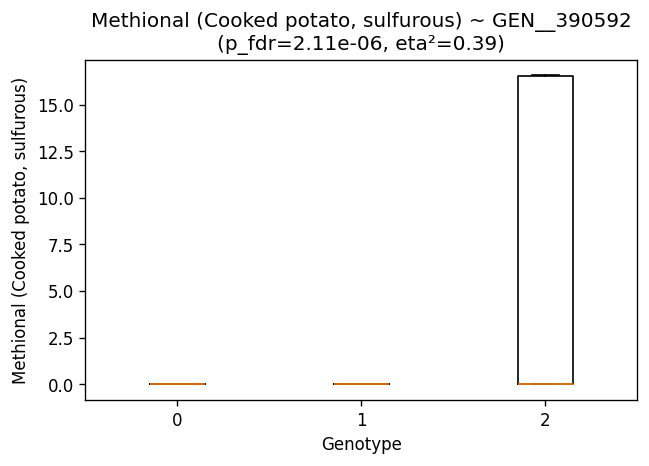
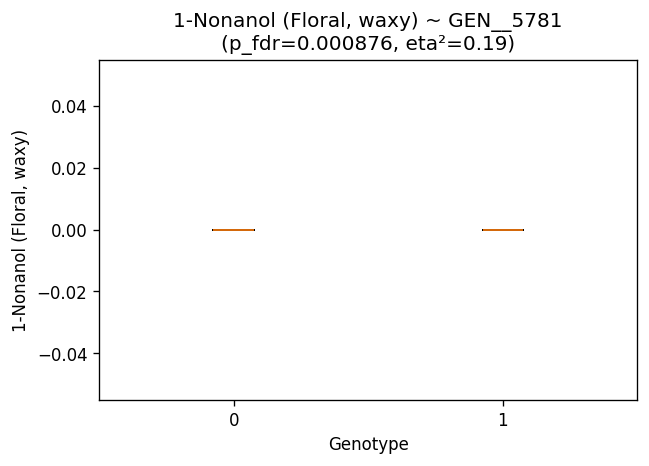
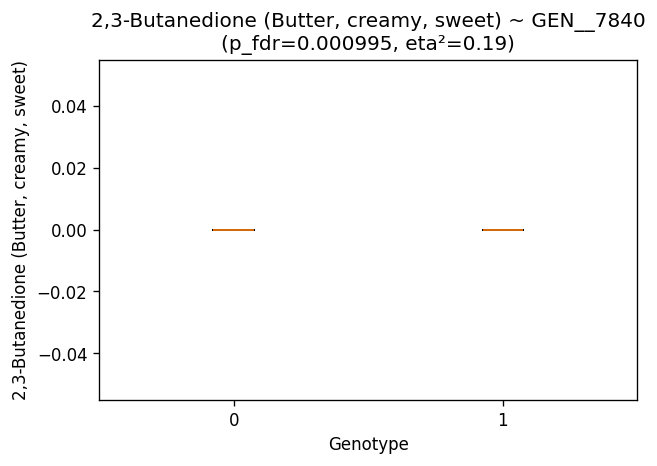
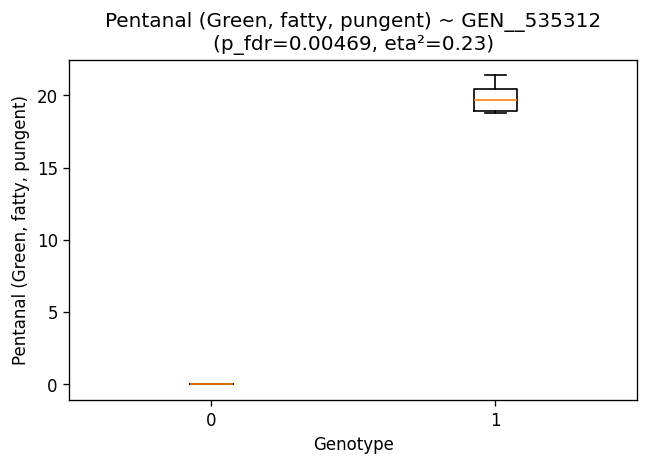
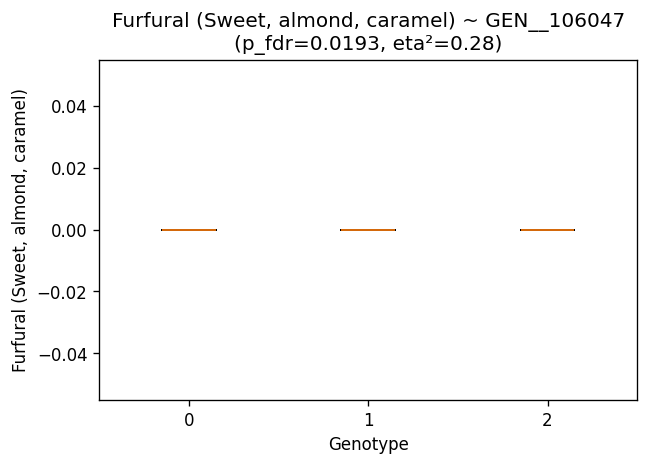
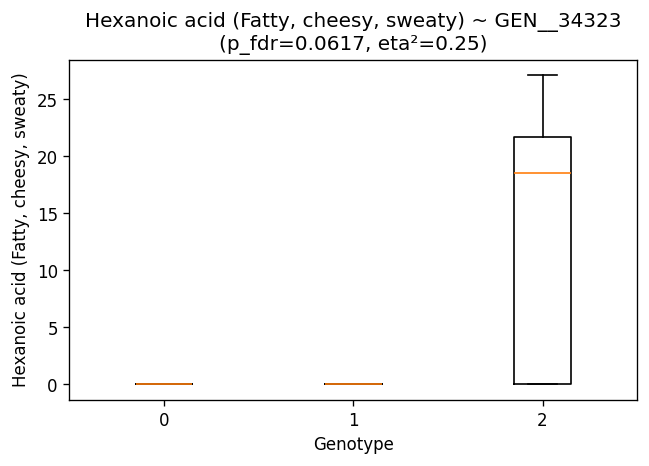
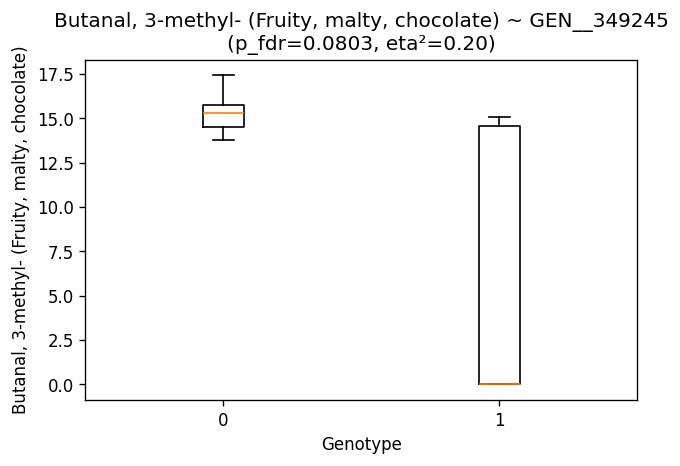
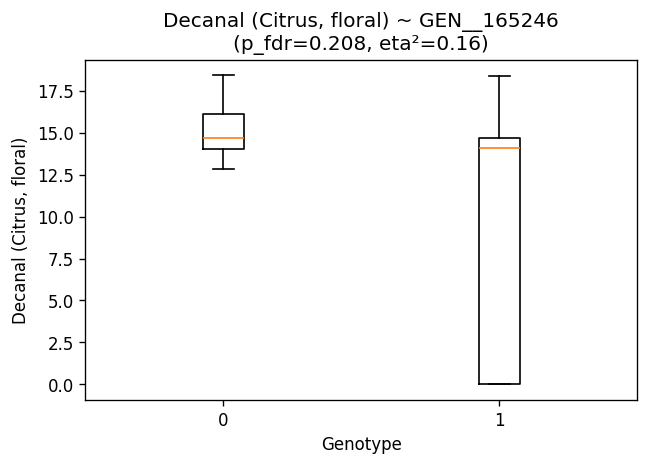
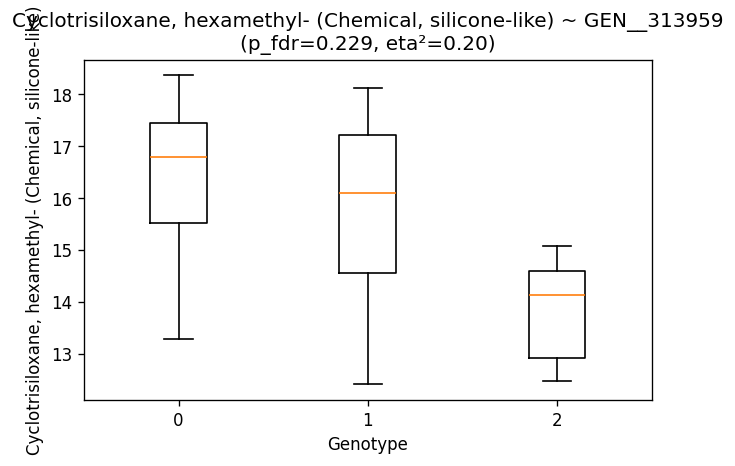
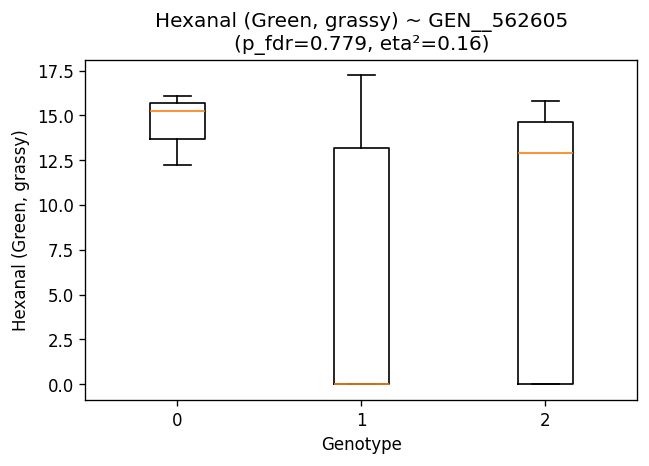
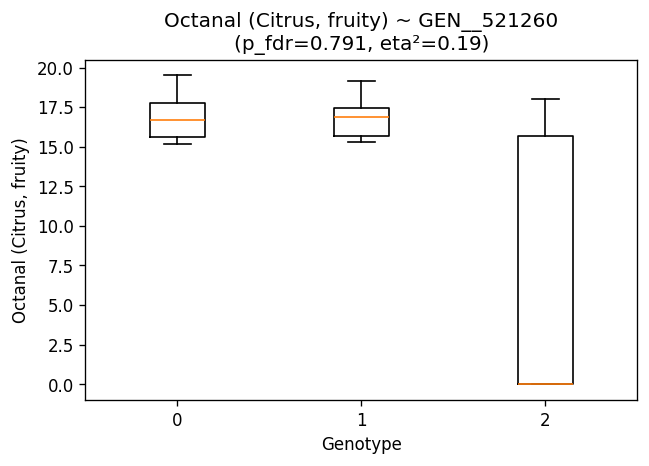
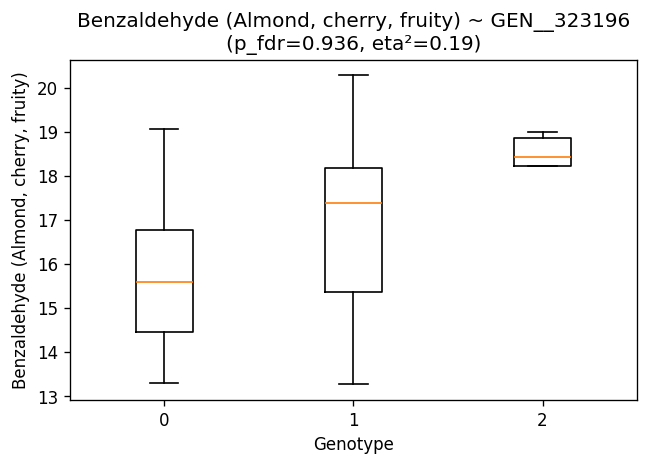
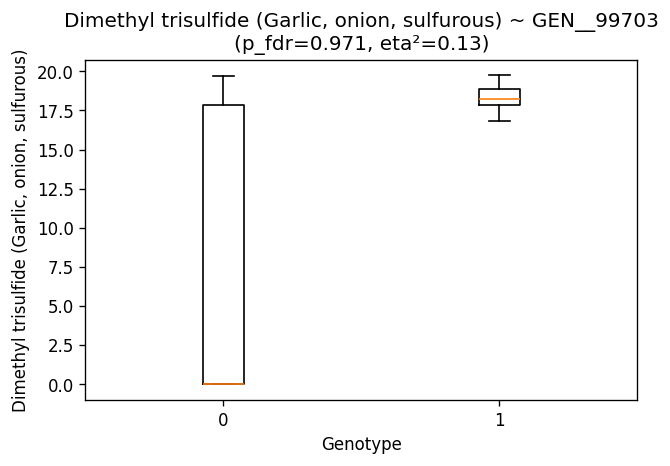

In [ ]:


# Configuaration
SIG_FDR = 0.05
MIN_GROUP = 5
PER_AROMA_MAX = 1
HTML_PATH = "aroma_genetics_dashboard.html"

# check Inputs 
if 'merged_all' not in globals():
    raise RuntimeError("merged_all not found. Build it first.")
if 'fast_big' not in globals():
    raise RuntimeError("fast_big (ANOVA hits) not found. Run the ANOVA step first.")
if 'aroma_cols' in globals():
    aroma_cols_present = [c for c in aroma_cols if c in merged_all.columns]
elif 'aroma_names' in globals():
    aroma_cols_present = [c for c in aroma_names if c in merged_all.columns]
else:
    raise RuntimeError("Provide aroma_cols or aroma_names.")

def collapse_ld(snps, df):
    if not snps: return [], {}
    G = df[snps].astype("float32").fillna(-9.0).to_numpy()
    keys = [tuple(col) for col in G.T]
    key2rep, rep2dups, kept = {}, {}, []
    for snp, key in zip(snps, keys):
        if key in key2rep:
            rep = key2rep[key]
            rep2dups.setdefault(rep, []).append(snp)
        else:
            key2rep[key] = snp
            kept.append(snp)
    return kept, rep2dups

def summarize_hit(df, aroma, snp, min_group=MIN_GROUP):
    y = df[aroma].astype(float).to_numpy()
    g = df[snp].astype(float).to_numpy()
    m = ~np.isnan(y) & ~np.isnan(g)
    y, g = y[m], g[m]
    if y.size < min_group*2: return None

    groups = {}
    for val in np.unique(g):
        idx = (g == val)
        n = int(idx.sum())
        if n > 0:
            groups[int(val)] = (n, float(y[idx].mean()), y[idx])

    present = [v for v,(n,_,arr) in groups.items() if n >= min_group]
    if len(present) < 2: return None

    ns  = np.array([groups[v][0] for v in present], float)
    mus = np.array([groups[v][1] for v in present], float)
    N   = int(ns.sum())
    gm  = float((ns*mus).sum()/N)
    ss_b = float((ns * (mus - gm)**2).sum())
    ss_w = float(sum(((groups[v][2] - groups[v][1])**2).sum() for v in present))
    eta2 = ss_b / (ss_b + ss_w) if (ss_b + ss_w) > 0 else np.nan

    H_kw, p_kw = kruskal(*[groups[v][2] for v in present])

    return {
        "eta2": eta2, "H_kw": float(H_kw), "p_kw": float(p_kw), "N": int(sum(groups[v][0] for v in groups)),
        "g0_n": int(groups.get(0,(0,np.nan,None))[0]), "g0_mu": float(groups.get(0,(0,np.nan,None))[1]) if 0 in groups else np.nan,
        "g1_n": int(groups.get(1,(0,np.nan,None))[0]), "g1_mu": float(groups.get(1,(0,np.nan,None))[1]) if 1 in groups else np.nan,
        "g2_n": int(groups.get(2,(0,np.nan,None))[0]), "g2_mu": float(groups.get(2,(0,np.nan,None))[1]) if 2 in groups else np.nan,
    }

def slug(s): return re.sub(r'[^A-Za-z0-9]+','_', str(s))[:80]

def boxplot_png_b64(df, aroma, snp, title_extra=""):
    y = df[aroma].astype(float).to_numpy()
    g = df[snp].astype(float).to_numpy()
    m = ~np.isnan(y) & ~np.isnan(g)
    y, g = y[m], g[m]
    data = [y[g==0], y[g==1], y[g==2]]
    tick_labels = [lab for lab, d in zip(["0","1","2"], data) if len(d)>0]
    data        = [d for d in data if len(d)>0]
    if len(data) < 2: return None

    fig, ax = plt.subplots(figsize=(5.5,4))
    #  use tick_labels to avoid the deprecation warning (Matplotlib ≥3.9)
    ax.boxplot(data, tick_labels=tick_labels, showfliers=False)
    ax.set_title(f"{aroma} ~ {snp}{title_extra}")
    ax.set_xlabel("Genotype"); ax.set_ylabel(aroma); fig.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode("ascii")

#ONE sentinel SNP per aroma 
sentinels = []
for aroma, sub in fast_big.groupby("aroma"):
    if aroma not in aroma_cols_present:
        continue
    sub = sub.sort_values(["p_fdr","p"])
    sig = sub[sub["p_fdr"] < SIG_FDR]
    candidates = sig if not sig.empty else sub
    snps_order = candidates["SNP"].tolist()
    if not snps_order:
        continue
    kept, rep2dups = collapse_ld(snps_order, merged_all)
    for snp in kept[:PER_AROMA_MAX]:
        row = candidates.loc[candidates["SNP"] == snp].iloc[0].to_dict()
        row["_dups"] = ", ".join(rep2dups.get(snp, []))
        sentinels.append(row)

if not sentinels:
    raise RuntimeError("No sentinel SNPs found. Check fast_big / SIG_FDR.")

# summary
rows, cards_html = [], []
for r in sentinels:
    aroma, snp = r["aroma"], r["SNP"]
    summ = summarize_hit(merged_all, aroma, snp)
    if not summ:
        continue
    rec = {**r, **summ}
    rows.append(rec)

summary = pd.DataFrame(rows)
summary = summary[["aroma","SNP","F","p","p_fdr","significant_fdr_0.05",
                   "eta2","H_kw","p_kw","N","g0_n","g0_mu","g1_n","g1_mu","g2_n","g2_mu","_dups"]]
summary = summary.sort_values(["p_fdr","p"]).reset_index(drop=True)

# Make boxplots as base64 and cards
for _, r in summary.iterrows():
    extra = f"\n(p_fdr={r['p_fdr']:.3g}, eta²={r['eta2']:.2f})"
    b64 = boxplot_png_b64(merged_all, r["aroma"], r["SNP"], title_extra=extra)
    if not b64:
        continue
    cards_html.append(f"""
    <div class="card">
      <div class="card-title">{r['aroma']}</div>
      <div class="card-sub">{r['SNP']}</div>
      <img src="data:image/png;base64,{b64}" alt="{r['aroma']} ~ {r['SNP']}">
      <div class="meta">FDR p: {r['p_fdr']:.3g} &nbsp; | &nbsp; eta²: {r['eta2']:.2f} &nbsp; | &nbsp; Kruskal p: {r['p_kw']:.3g}</div>
    </div>
    """)

# dashboard
tbl_html = summary.round(4).to_html(index=False, escape=True)
html = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Aroma × Genetics Dashboard</title>
<style>
body {{ font-family: Arial, sans-serif; margin: 20px; }}
h1 {{ margin-top: 0; }}
.table-wrap {{ overflow-x: auto; margin-bottom: 24px; }}
.grid {{ display: grid; grid-template-columns: repeat(auto-fill, minmax(340px, 1fr)); gap: 16px; }}
.card {{ border: 1px solid #ddd; border-radius: 10px; padding: 12px; }}
.card-title {{ font-weight: 700; margin-bottom: 2px; }}
.card-sub {{ color: #555; font-size: 0.9em; margin-bottom: 8px; }}
.card img {{ width: 100%; height: auto; border-radius: 6px; }}
.meta {{ color: #444; font-size: 0.85em; margin-top: 6px; }}
</style>
</head>
<body>
  <h1>Aroma × Genetics Dashboard (Sentinel SNP per aroma)</h1>
  <div class="table-wrap">{tbl_html}</div>
  <div class="grid">
    {''.join(cards_html)}
  </div>
</body>
</html>
"""

with open(HTML_PATH, "w", encoding="utf-8") as f:
    f.write(html)
display(HTML(filename=HTML_PATH))


tested SNP × aroma combinations. As can be seen, for some aromas (like 1-Nonanol), certain SNPs are significantly associated with variation in compound levels, these are strong candidates for genetic control of aroma. However, For others (like Pentanal), no SNPs passed the significance threshold.

# Genetics-only HCA (population structure)

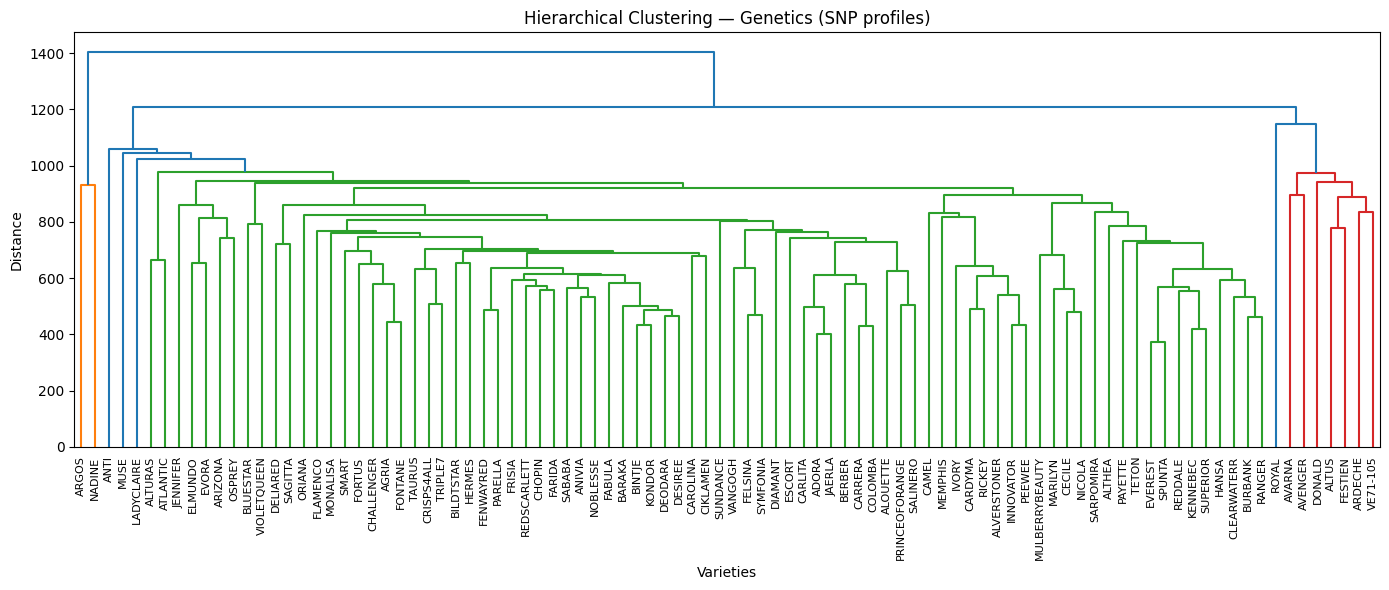

        Variety  Cluster_gen_k9
10        ARGOS               1
65       NADINE               1
12     ATLANTIC               2
4       ALTURAS               2
3        ALTHEA               3
6   ALVERSTONER               3
2      ALOUETTE               3
0         ADORA               3
15       BARAKA               3
7        ANIVIA               3
11      ARIZONA               3
20      BURBANK               3
19     BLUESTAR               3
18       BINTJE               3
17    BILDTSTAR               3
1         AGRIA               3
24     CAROLINA               3
25      CARRERA               3
26       CECILE               3
27   CHALLENGER               3


In [ ]:


#Build genetics matrix (rows=varieties, cols=SNPs)
snp_cols = [c for c in merged_all.columns if c.startswith("GEN__")]
X_gen = merged_all[snp_cols].copy()

# drop constant SNPs
X_gen = X_gen.loc[:, X_gen.std(ddof=0) > 0]

# Standardize
X_gen_z = StandardScaler().fit_transform(X_gen)

# Linkage (Ward + Euclidean)
Z_gen = linkage(X_gen_z, method="ward", metric="euclidean")

# Dendrogram
plt.figure(figsize=(14, 6))
dendrogram(Z_gen, labels=X_gen.index.tolist(), leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering — Genetics (SNP profiles)")
plt.xlabel("Varieties"); plt.ylabel("Distance")
plt.tight_layout(); plt.show()

# Cut into k clusters and export table (set k as you wish)
k_gen = 9
clusters_gen = fcluster(Z_gen, k_gen, criterion="maxclust")
hca_gen = pd.DataFrame({"Variety": X_gen.index, f"Cluster_gen_k{k_gen}": clusters_gen}) \
            .sort_values(f"Cluster_gen_k{k_gen}")
print(hca_gen.head(20))
# hca_gen.to_csv(f"hca_clusters_genetic_k{k_gen}.csv", index=False)


Aroma-only HCA (phenotypic groupings)

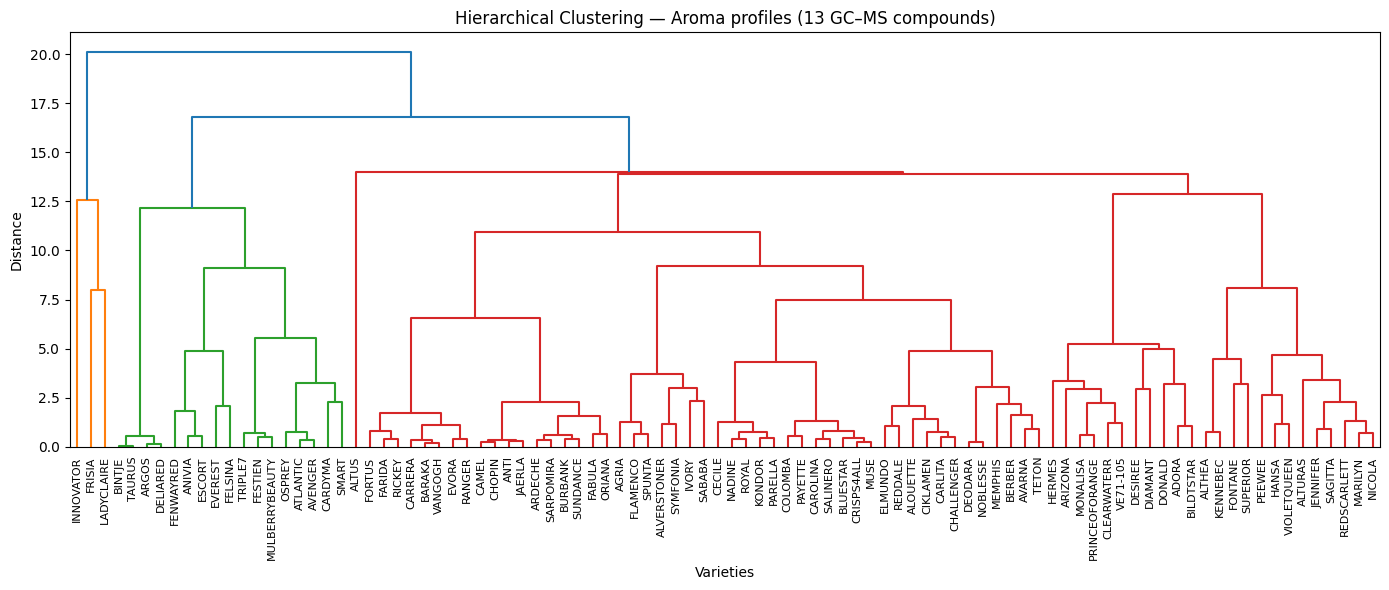

           Variety  Cluster_aroma_k9
50          FRISIA                 1
59      LADYCLAIRE                 1
53       INNOVATOR                 2
10           ARGOS                 3
33        DELIARED                 3
18          BINTJE                 3
88          TAURUS                 3
12        ATLANTIC                 4
40         EVEREST                 4
46         FESTIEN                 4
39          ESCORT                 4
44         FELSINA                 4
22         CARDYMA                 4
14         AVENGER                 4
45       FENWAYRED                 4
7           ANIVIA                 4
90         TRIPLE7                 4
83           SMART                 4
69          OSPREY                 4
63  MULBERRYBEAUTY                 4


In [11]:
# --- Aroma-only HCA (13 GC–MS compounds) ---

# 1) Aroma columns (your whitelist of 13 compounds)
aroma_cols = [
    '1-Nonanol (Floral, waxy)',
    '2,3-Butanedione (Butter, creamy, sweet)',
    'Benzaldehyde (Almond, cherry, fruity)',
    'Butanal, 3-methyl- (Fruity, malty, chocolate)',
    'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)',
    'Decanal (Citrus, floral)',
    'Dimethyl trisulfide (Garlic, onion, sulfurous)',
    'Furfural (Sweet, almond, caramel)',
    'Hexanal (Green, grassy)',
    'Hexanoic acid (Fatty, cheesy, sweaty)',
    'Methional (Cooked potato, sulfurous)',
    'Octanal (Citrus, fruity)',
    'Pentanal (Green, fatty, pungent)',
]

X_aroma = merged_all[aroma_cols].copy()

# 2) Standardize
X_aroma_z = StandardScaler().fit_transform(X_aroma)

# 3) Linkage (Ward + Euclidean)
Z_aroma = linkage(X_aroma_z, method="ward", metric="euclidean")

# 4) Dendrogram
plt.figure(figsize=(14, 6))
dendrogram(Z_aroma, labels=merged_all.index.tolist(), leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering — Aroma profiles (13 GC–MS compounds)")
plt.xlabel("Varieties"); plt.ylabel("Distance")
plt.tight_layout(); plt.show()

# 5) Cut into k clusters and export table (set k as you wish)
k_aroma = 9
clusters_aroma = fcluster(Z_aroma, k_aroma, criterion="maxclust")
hca_aroma = pd.DataFrame({"Variety": merged_all.index, f"Cluster_aroma_k{k_aroma}": clusters_aroma}) \
              .sort_values(f"Cluster_aroma_k{k_aroma}")
print(hca_aroma.head(20))
# hca_aroma.to_csv(f"hca_clusters_aroma_k{k_aroma}.csv", index=False)


# Since k=9 has the highest  silhouette score we select this for clustering(HCA)

In [12]:


# --- 1) Select features ---
snp_cols = [c for c in merged_all.columns if c.startswith("GEN__")]
X_combo = merged_all[snp_cols + aroma_cols].copy()

# --- 2) Standardize ---
scaler = StandardScaler()
X_combo_scaled = scaler.fit_transform(X_combo)

# --- 3) Build linkage tree ---
Z_combo = linkage(X_combo_scaled, method="ward", metric="euclidean")

# --- 4) Evaluate k ---
k_range = range(2, 13)
sil_scores, ch_scores, db_scores = [], [], []

# cophenetic correlation (quality of tree)
D = pdist(X_combo_scaled, metric="euclidean")
coph_corr, _ = cophenet(Z_combo, D)
print(f"Cophenetic correlation of linkage: {coph_corr:.3f}")

for k in k_range:
    labels = fcluster(Z_combo, k, criterion="maxclust")
    sil_scores.append(silhouette_score(X_combo_scaled, labels, metric="euclidean"))
    ch_scores.append(calinski_harabasz_score(X_combo_scaled, labels))
    db_scores.append(davies_bouldin_score(X_combo_scaled, labels))

# --- 5) Pick best k (max silhouette) ---
best_k = k_range[int(np.argmax(sil_scores))]
print("\n=== Clustering evaluation ===")
print("k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin")
for k, si, ch, db in zip(k_range, sil_scores, ch_scores, db_scores):
    print(f"{k:2d} |   {si:8.3f}   |     {ch:10.1f}     |     {db:6.3f}")
print(f"\nSelected best k by silhouette: k={best_k}")

# --- 6) Cut dendrogram at best_k and export ---
clusters_best = fcluster(Z_combo, best_k, criterion="maxclust")
hca_combo_best = pd.DataFrame({
    "Variety": merged_all.index,
    f"Cluster_combo_k{best_k}": clusters_best
}).sort_values(f"Cluster_combo_k{best_k}")

print("\n=== Cluster assignment (first 20 rows) ===")
print(hca_combo_best.head(20))

# --- 7) Cluster sizes ---
counts = hca_combo_best[f"Cluster_combo_k{best_k}"].value_counts().sort_index()
print("\nCluster sizes:")
print(counts.to_string())


Cophenetic correlation of linkage: 0.758

=== Clustering evaluation ===
k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin
 2 |      0.280   |            3.8     |      1.347
 3 |      0.167   |            3.4     |      2.756
 4 |      0.154   |            3.2     |      2.111
 5 |      0.155   |            3.0     |      1.827
 6 |      0.157   |            2.9     |      1.638
 7 |      0.157   |            2.8     |      1.505
 8 |      0.103   |            2.7     |      1.515
 9 |      0.105   |            2.7     |      1.425
10 |      0.088   |            2.6     |      1.609
11 |      0.090   |            2.6     |      1.471
12 |      0.090   |            2.6     |      1.491

Selected best k by silhouette: k=2

=== Cluster assignment (first 20 rows) ===
        Variety  Cluster_combo_k2
10        ARGOS                 1
65       NADINE                 1
2      ALOUETTE                 2
0         ADORA                 2
4       ALTURAS                 2
5         ALTU

ARGOS and NADINE may have unique genetic–aroma profiles that separate them clearly from the rest.

The other 92 varieties form a large homogeneous group where differences are less distinct at the scale of your combined data.

# Corrolation between Aroma Clusters and Genetic Markers

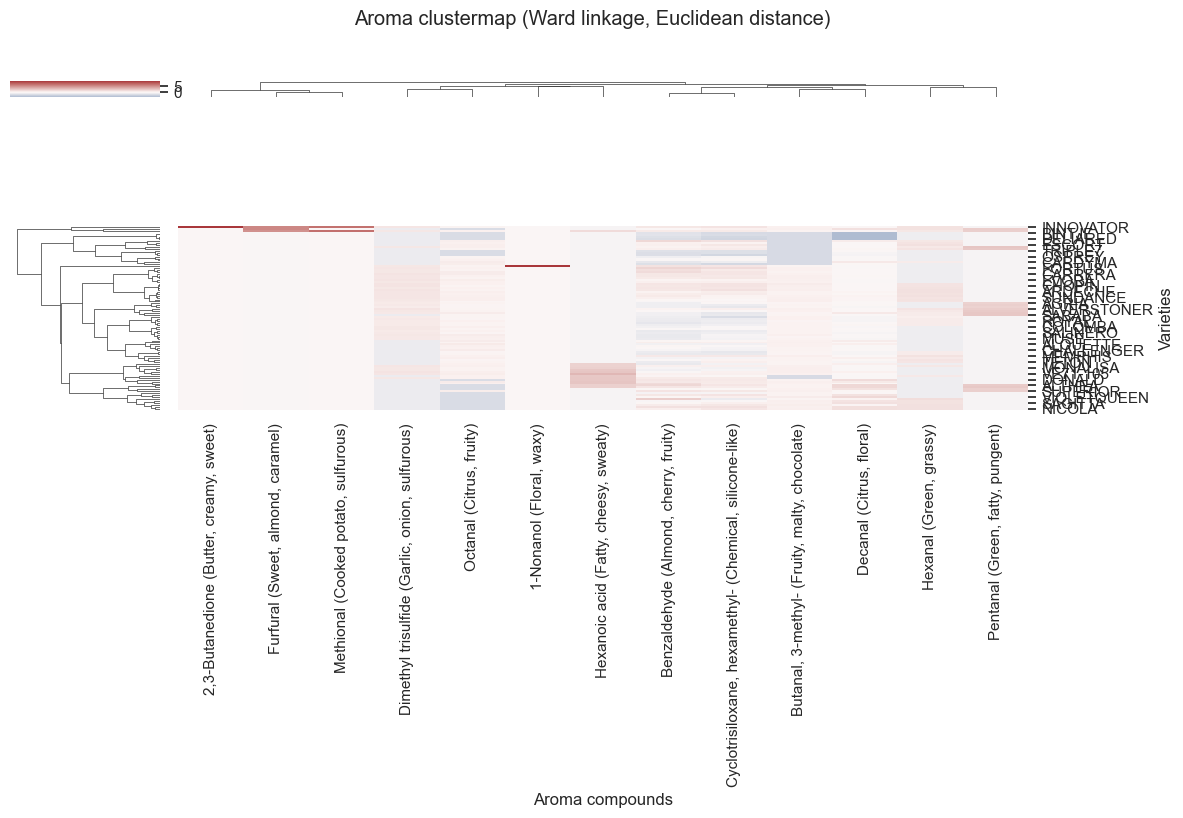

Cluster means (z-scored):


,"1-Nonanol (Floral, waxy)","2,3-Butanedione (Butter, creamy, sweet)","Benzaldehyde (Almond, cherry, fruity)","Butanal, 3-methyl- (Fruity, malty, chocolate)","Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)","Decanal (Citrus, floral)","Dimethyl trisulfide (Garlic, onion, sulfurous)","Furfural (Sweet, almond, caramel)","Hexanal (Green, grassy)","Hexanoic acid (Fatty, cheesy, sweaty)","Methional (Cooked potato, sulfurous)","Octanal (Citrus, fruity)","Pentanal (Green, fatty, pungent)"
cluster,,,,,,,,,,,,,
1,-0.10,3.15,0.60,0.49,0.84,0.53,0.39,5.50,1.18,0.23,4.47,-0.32,1.33
2,-0.10,-0.10,-0.71,-1.98,-0.78,-0.91,-0.86,-0.18,-0.20,-0.41,-0.15,-0.42,-0.09
3,-0.10,-0.10,-0.07,0.48,-0.02,-0.04,0.48,-0.18,0.10,-0.41,-0.15,0.52,-0.05
4,-0.10,-0.10,0.52,0.34,0.44,0.67,-0.47,-0.18,-0.17,1.12,-0.15,-0.73,0.02
5,9.64,-0.10,1.25,0.36,1.07,-0.27,1.05,-0.18,-0.89,-0.41,-0.15,0.43,-0.43


Cluster means (raw scale):


,"1-Nonanol (Floral, waxy)","2,3-Butanedione (Butter, creamy, sweet)","Benzaldehyde (Almond, cherry, fruity)","Butanal, 3-methyl- (Fruity, malty, chocolate)","Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)","Decanal (Citrus, floral)","Dimethyl trisulfide (Garlic, onion, sulfurous)","Furfural (Sweet, almond, caramel)","Hexanal (Green, grassy)","Hexanoic acid (Fatty, cheesy, sweaty)","Methional (Cooked potato, sulfurous)","Octanal (Citrus, fruity)","Pentanal (Green, fatty, pungent)"
cluster,,,,,,,,,,,,,
1,0.000,6.435,17.445,15.286,17.304,16.815,12.450,13.912,15.219,4.740,11.039,10.855,13.008
2,0.000,0.000,15.171,0.000,14.762,11.378,1.093,0.000,5.103,0.000,0.000,10.149,2.565
3,0.000,0.000,16.273,15.215,15.953,14.666,13.327,0.000,7.260,0.000,0.000,16.825,2.833
4,0.000,0.000,17.305,14.300,16.681,17.365,4.657,0.000,5.271,11.291,0.000,7.956,3.312
5,18.539,0.000,18.570,14.457,17.676,13.812,18.493,0.000,0.000,0.000,0.000,16.247,0.000


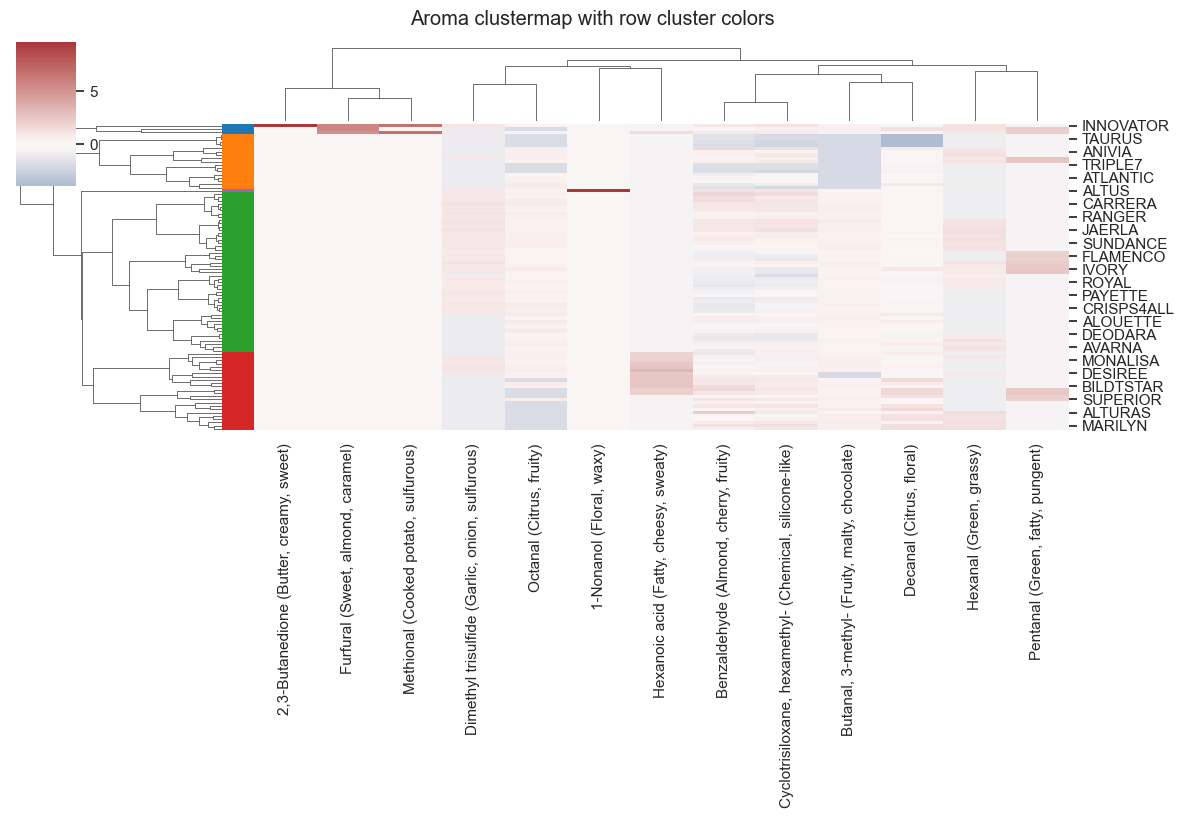

In [ ]:
# Heatmap + hierarchical clustering of varieties by aroma profiles

# standardize columns (z-score per aroma so they are comparable)
scaler = StandardScaler()
Xz = pd.DataFrame(
    scaler.fit_transform(X.values),
    index=X.index, columns=X.columns
)

#  clustermap 
sns.set(context="notebook")
cg = sns.clustermap(
    Xz,
    method="ward", metric="euclidean",
    cmap="vlag", center=0,
    linewidths=0.0, figsize=(12, 8),
    row_cluster=True, col_cluster=True,
    dendrogram_ratio=(.15, .08),
    cbar_pos=(0.02, .8, .02, .15)  # (x, y, width, height)
)
cg.ax_heatmap.set_xlabel("Aroma compounds")
cg.ax_heatmap.set_ylabel("Varieties")
cg.fig.suptitle("Aroma clustermap (Ward linkage, Euclidean distance)", y=1.02)

plt.tight_layout()
plt.show()

# get cluster labels for varieties
# choose number of clusters you want on rows (varieties)
k = 5
row_linkage = cg.dendrogram_row.linkage
row_clusters = fcluster(row_linkage, t=k, criterion="maxclust")

clusters_df = pd.DataFrame({
    "Variety": Xz.index,
    "cluster": row_clusters
}).set_index("Variety")

# summarize cluster-wise aroma means (on original scale and z-scored)
cluster_means_z = (
    Xz.join(clusters_df)
      .groupby("cluster")[aroma_cols]
      .mean()
      .sort_index()
)

cluster_means_raw = (
    X.join(clusters_df)
     .groupby("cluster")[aroma_cols]
     .mean()
     .sort_index()
)

print("Cluster means (z-scored):")
display(cluster_means_z.round(2))
print("Cluster means (raw scale):")
display(cluster_means_raw.round(3))


# assign a color per cluster for nicer row annotation
palette = sns.color_palette("tab10", n_colors=k)
row_colors = [palette[c-1] for c in row_clusters]

cg2 = sns.clustermap(
    Xz, method="ward", metric="euclidean",
    cmap="vlag", center=0, figsize=(12,8),
    row_colors=row_colors, col_cluster=True
)
cg2.fig.suptitle("Aroma clustermap with row cluster colors", y=1.02)
plt.show()


Figures

Figure 1. Hierarchical clustering heatmap of potato varieties based on aroma compound profiles (Ward linkage, Euclidean distance).

Figure 2. Hierarchical clustering heatmap of potato varieties with row cluster color annotations.

Tables

Table 1. Cluster-wise mean aroma intensities (z-scored values) across 13 aroma compounds.

Table 2. Cluster-wise mean aroma intensities (raw values) across 13 aroma compounds.

ANOVA tells you which SNPs control specific aroma compounds.

Clusters tell you which aromas dominate groups of varieties.

The relation: SNPs linked to cluster-defining aromas (e.g., 1-Nonanol, Furfural) are likely genetic drivers of those aroma clusters.

# links aroma clusters to significant SNPs  
reports which markers are enriched in which clusters.

In [ ]:

OUTDIR = Path("cluster_snp_outputs")
OUTDIR.mkdir(exist_ok=True, parents=True)


#  Get/Build cluster labels (k clusters via HCA)

try:
    clusters_df
except NameError:
    aroma_cols = merged_aroma_cols
    X = merged_all[aroma_cols].astype(float).fillna(0)
    Xz = pd.DataFrame(StandardScaler().fit_transform(X), index=X.index, columns=X.columns)
    Z = linkage(Xz, method="ward", metric="euclidean")
    K_CLUSTERS = 5  # change if you prefer another k
    labels = fcluster(Z, t=K_CLUSTERS, criterion="maxclust")
    clusters_df = pd.DataFrame({"cluster": labels}, index=X.index)

# Pick candidate SNPs from ANOVA results

try:
    # If you already have a filtered table called `tops`
    sig_table = tops.copy()
except NameError:
    anova_path = Path("anova_outputs") / "snp_anova_all_aromas_combined.csv"
    sig_table = pd.read_csv(anova_path)
    if (sig_table["significant_fdr_0.05"]).any():
        sig_table = sig_table[sig_table["significant_fdr_0.05"]]
    else:
        # fallback: take top by raw p per aroma
        sig_table = (sig_table
                     .sort_values(["aroma","p"])
                     .groupby("aroma")
                     .head(300))

snp_all_cols = [c for c in merged_all.columns if c.startswith("GEN__")]
snp_list = sorted(set(sig_table["SNP"]) & set(snp_all_cols))
if len(snp_list) == 0:
    raise ValueError("No candidate SNPs found in merged_all. Check ANOVA outputs or column prefix.")


#  χ² test SNP ↔ cluster + Cramér’s V + FDR

rows = []
count_frames = []

for snp in snp_list:
    g = merged_all[snp]
    dfc = pd.concat([g, clusters_df["cluster"]], axis=1).dropna()
    if dfc.empty: 
        continue

    # round/clip to 0/1/2 (handles float genotypes)
    geno = np.clip(np.rint(dfc[snp].astype(float)).astype(int), 0, 2)
    dfc = dfc.assign(geno=geno)

    # Build contingency table: clusters x genotypes
    tab = pd.crosstab(dfc["cluster"], dfc["geno"])
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        continue

    chi2, p, dof, exp = chi2_contingency(tab)
    n = tab.values.sum()
    r, k = tab.shape
    cramers_v = float(np.sqrt(chi2 / (n * (min(r-1, k-1)))))

    rows.append({
        "SNP": snp, "chi2": chi2, "p": p, "dof": dof, "n": int(n), "cramers_v": cramers_v
    })

    # keep counts (long format) for inspection/plots
    long_counts = (tab
                   .reset_index()
                   .melt(id_vars="cluster", var_name="genotype", value_name="count")
                   .assign(SNP=snp))
    count_frames.append(long_counts)

assoc = pd.DataFrame(rows).sort_values("p").reset_index(drop=True)
if not assoc.empty:
    assoc["p_fdr"] = multipletests(assoc["p"], method="fdr_bh")[1]
    assoc["significant_fdr_0.05"] = assoc["p_fdr"] < 0.05

assoc.to_csv(OUTDIR / "snp_cluster_enrichment.csv", index=False)

counts_long = pd.concat(count_frames, ignore_index=True) if count_frames else pd.DataFrame()
counts_long.to_csv(OUTDIR / "snp_cluster_counts.csv", index=False)

print(f"Saved: {OUTDIR/'snp_cluster_enrichment.csv'}")
print(f"Saved: {OUTDIR/'snp_cluster_counts.csv'}")

#  Mean genotype per cluster (top significant SNPs)

top_sig_snps = atop_sig_snps = assoc[assoc["significant_fdr_0.05"]].head(30)["SNP"].tolist() if not assoc.empty else []

geno_means = (merged_all[top_sig_snps].join(clusters_df).groupby("cluster")[top_sig_snps].mean().sort_index())

geno_means

Saved: cluster_snp_outputs\snp_cluster_enrichment.csv
Saved: cluster_snp_outputs\snp_cluster_counts.csv


,GEN__333797,GEN__241392,GEN__260011,GEN__260106,GEN__390592,GEN__350063,GEN__288637,GEN__348089,GEN__397703,GEN__56770,...,GEN__243267,GEN__6638,GEN__106084,GEN__106048,GEN__106047,GEN__165246,GEN__165303,GEN__385333,GEN__385332,GEN__319819
cluster,,,,,,,,,,,,,,,,,,,,,
1,0.666667,0.333333,0.000000,0.000000,1.333333,0.000000,0.666667,0.000000,0.000000,0.000000,...,0.666667,0.666667,2.666667,2.666667,2.666667,0.000000,0.000000,1.000000,1.000000,1.333333
2,0.058824,1.176471,0.117647,0.117647,0.352941,0.117647,0.000000,0.058824,0.058824,0.058824,...,1.294118,1.411765,1.117647,1.117647,1.117647,0.352941,0.352941,0.235294,0.235294,0.294118
3,0.061224,1.204082,0.040816,0.040816,0.448980,0.020408,0.040816,0.020408,0.061224,0.061224,...,1.367347,1.387755,0.755102,0.755102,0.755102,0.040816,0.040816,0.244898,0.244898,0.408163
4,0.000000,1.333333,0.000000,0.000000,0.541667,0.041667,0.083333,0.083333,0.000000,0.000000,...,1.416667,1.375000,0.708333,0.708333,0.708333,0.041667,0.041667,0.125000,0.125000,0.541667
5,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000


Certain SNPs clearly separate clusters.

For example:

GEN__350063 and GEN__397703 are genetic markers of Cluster 5 (1-Nonanol–rich cluster).

GEN__106084, GEN__106048, GEN__106047 are genetic markers of Cluster 1 (Furfural/Methional–rich cluster).

In short: each aroma cluster has not only a unique chemical aroma profile, but also a distinct SNP genetic signature.

# GWAS pipeline (aroma compounds as phenotypes, SNPs as predictors)

In [ ]:
# ---------- FAST GWAS (vectorized; per-SNP MAF + min group filter) ----------
# Requirements: numpy, pandas, scipy (t distribution), statsmodels (FDR)


# ----- CONFIG -----
AROMA_COLS = merged_aroma_cols          # your 13 aroma columns
SNP_PREFIX = "GEN__"
K_PCS      = 10                         # set 0 to skip PCs (faster, less robust)
CHUNK      = 8000                       # SNPs per chunk
MIN_MAF    = 0.05                       # minor allele frequency threshold
MIN_GROUP  = 5                          # min samples per genotype in at least 2 groups
OUTDIR     = Path("gwas_fast_outputs"); OUTDIR.mkdir(exist_ok=True, parents=True)

# ----- 1) Build genotype matrix and apply robust per-SNP filters -----
snp_cols_all = [c for c in merged_all.columns if c.startswith(SNP_PREFIX)]
G_raw = merged_all[snp_cols_all].to_numpy(dtype=np.float32)   # n x m (with NaNs)
n, m0 = G_raw.shape

# Mean-impute for computations
G = G_raw.copy()
col_means = np.nanmean(G, axis=0)
inds = np.where(np.isnan(G))
G[inds] = col_means[inds[1]]

# Per-SNP scale: 2 if any value >1.5 (0/1/2 SNP), else 1 (0/1 SNP)
max_per_snp = np.nanmax(G_raw, axis=0)
scale = np.where(max_per_snp > 1.5, 2.0, 1.0)

# Per-SNP MAF (correct)
p = np.nanmean(G / scale, axis=0)
maf = np.minimum(p, 1.0 - p)

# Per-SNP genotype counts (on raw, before impute; round to nearest int)
G_int = np.rint(G_raw).astype(np.float32)
g0 = np.nansum(G_int == 0, axis=0)
g1 = np.nansum(G_int == 1, axis=0)
g2 = np.nansum(G_int == 2, axis=0)

# Require at least two genotype groups with >= MIN_GROUP samples
min_group_ok = ((g0 >= MIN_GROUP) & (g1 >= MIN_GROUP)) | \
               ((g0 >= MIN_GROUP) & (g2 >= MIN_GROUP)) | \
               ((g1 >= MIN_GROUP) & (g2 >= MIN_GROUP))

# Variance check (after impute)
var_ok = np.nanstd(G, axis=0) > 0

keep = (maf >= MIN_MAF) & var_ok & min_group_ok
G = G[:, keep]
snp_cols = [c for c, k in zip(snp_cols_all, keep) if k]
n, m = G.shape
print(f"After filters: {n} x {m} SNPs kept (from {m0}).  "
      f"MIN_MAF={MIN_MAF}, MIN_GROUP={MIN_GROUP}")

if m == 0:
    raise ValueError("No SNPs passed filters. Lower MIN_MAF or MIN_GROUP and retry.")

# ----- 2) Compute genotype PCs (optional but recommended) -----
def compute_pcs(G, k=10):
    Gc = G - G.mean(axis=0, keepdims=True)
    K = (Gc @ Gc.T) / Gc.shape[1]           # n x n kinship
    evals, evecs = np.linalg.eigh(K)        # ascending eigenvalues
    return evecs[:, -k:]                    # top k PCs (n x k)

Z_cov = np.ones((n, 1), dtype=np.float32)   # intercept
if K_PCS > 0:
    k_use = min(K_PCS, max(0, n - 3))       # keep df positive
    if k_use > 0:
        PCs = compute_pcs(G, k=k_use).astype(np.float32)
        Z_cov = np.concatenate([Z_cov, PCs], axis=1)
print("Covariates shape (intercept + PCs):", Z_cov.shape)  # n x q

# ----- 3) Core GWAS (vectorized correlations on residuals) -----
def gwas_once(y, G, Z, snp_names, chunk=10000):
    mask = ~np.isnan(y)
    y = y[mask].astype(np.float64)
    Zm = Z[mask, :].astype(np.float64)
    Gm = G[mask, :].astype(np.float64)
    n_eff, q = y.shape[0], Zm.shape[1]
    df = n_eff - q - 1
    if df <= 0:
        raise ValueError(f"Not enough df (n={n_eff}, covariates={q}). Reduce K_PCS.")

    # residualize y on Z
    ZTZ_inv = np.linalg.inv(Zm.T @ Zm)
    y_res = y - Zm @ (ZTZ_inv @ (Zm.T @ y))
    y_res -= y_res.mean()
    denom_y = np.sqrt(np.sum(y_res**2)) + 1e-12

    pvals = np.empty(Gm.shape[1], dtype=np.float64)
    for s in range(0, Gm.shape[1], chunk):
        Ge = Gm[:, s:s+chunk]
        Ge_res = Ge - Zm @ (ZTZ_inv @ (Zm.T @ Ge))      # residualize SNPs
        Ge_res -= Ge_res.mean(axis=0, keepdims=True)    # center columns
        denom_g = np.sqrt(np.sum(Ge_res**2, axis=0)) + 1e-12

        r = (y_res @ Ge_res) / (denom_y * denom_g)
        r = np.clip(r, -0.999999999, 0.999999999)
        t = r * np.sqrt(df / (1.0 - r*r))
        pvals[s:s+chunk] = 2.0 * tdist.sf(np.abs(t), df)

    out = pd.DataFrame({"SNP": snp_names, "p": pvals})
    return out, df

# ----- 4) Run GWAS per aroma and save -----
all_res = []
for aroma in AROMA_COLS:
    if aroma not in merged_all.columns:
        continue
    y = merged_all[aroma].to_numpy(dtype=np.float32)

    res, df_aroma = gwas_once(y, G, Z_cov, snp_cols, chunk=CHUNK)

    reject, p_fdr, _, _ = multipletests(res["p"].values, method="fdr_bh")
    res.insert(0, "aroma", aroma)
    res["p_fdr"] = p_fdr
    res["significant_fdr_0.05"] = reject

    fname = OUTDIR / f"gwas_fast_{aroma.replace(' ','_').replace('/','_')}.csv"
    res.sort_values("p").to_csv(fname, index=False)
    print(f"Saved: {fname}")
    all_res.append(res)

# ----- 5) Combined summary -----
if all_res:
    big = pd.concat(all_res, ignore_index=True)
    big.to_csv(OUTDIR / "gwas_fast_all_aromas.csv", index=False)
    print("Saved combined:", OUTDIR / "gwas_fast_all_aromas.csv")
else:
    print("No results produced.")


After filters: 94 x 101602 SNPs kept (from 262434).  MIN_MAF=0.05, MIN_GROUP=5
Covariates shape (intercept + PCs): (94, 11)
Saved: gwas_fast_outputs\gwas_fast_1-Nonanol_(Floral,_waxy).csv
Saved: gwas_fast_outputs\gwas_fast_2,3-Butanedione_(Butter,_creamy,_sweet).csv
Saved: gwas_fast_outputs\gwas_fast_Benzaldehyde_(Almond,_cherry,_fruity).csv
Saved: gwas_fast_outputs\gwas_fast_Butanal,_3-methyl-_(Fruity,_malty,_chocolate).csv
Saved: gwas_fast_outputs\gwas_fast_Cyclotrisiloxane,_hexamethyl-_(Chemical,_silicone-like).csv
Saved: gwas_fast_outputs\gwas_fast_Decanal_(Citrus,_floral).csv
Saved: gwas_fast_outputs\gwas_fast_Dimethyl_trisulfide_(Garlic,_onion,_sulfurous).csv
Saved: gwas_fast_outputs\gwas_fast_Furfural_(Sweet,_almond,_caramel).csv
Saved: gwas_fast_outputs\gwas_fast_Hexanal_(Green,_grassy).csv
Saved: gwas_fast_outputs\gwas_fast_Hexanoic_acid_(Fatty,_cheesy,_sweaty).csv
Saved: gwas_fast_outputs\gwas_fast_Methional_(Cooked_potato,_sulfurous).csv
Saved: gwas_fast_outputs\gwas_fast_Oc

# Load the combined results and peek

In [ ]:
outdir = Path("gwas_fast_outputs")
big = pd.read_csv(outdir / "gwas_fast_all_aromas.csv")
big.head()


,aroma,SNP,p,p_fdr,significant_fdr_0.05
0,"1-Nonanol (Floral, waxy)",GEN__56,0.978980,0.999982,False
1,"1-Nonanol (Floral, waxy)",GEN__57,0.180120,0.999982,False
2,"1-Nonanol (Floral, waxy)",GEN__60,0.978980,0.999982,False
3,"1-Nonanol (Floral, waxy)",GEN__61,0.978980,0.999982,False
4,"1-Nonanol (Floral, waxy)",GEN__124,0.838085,0.999982,False


# How many significant SNPs per aroma?

In [20]:
(big[big["significant_fdr_0.05"]]
 .groupby("aroma")["SNP"]
 .count()
 .sort_values(ascending=False))


aroma
1-Nonanol (Floral, waxy)                   586
Pentanal (Green, fatty, pungent)           278
Methional (Cooked potato, sulfurous)         8
2,3-Butanedione (Butter, creamy, sweet)      1
Name: SNP, dtype: int64

# Top hits per aroma (nice shortlist)

In [21]:
top10 = (big.sort_values(["aroma","p_fdr","p"])
             .groupby("aroma", as_index=False)
             .head(10))
top10
# (Optional) save:
top10.to_csv(outdir / "gwas_fast_top10_per_aroma.csv", index=False)
top10

,aroma,SNP,p,p_fdr,significant_fdr_0.05
64430,"1-Nonanol (Floral, waxy)",GEN__344339,1.323850e-10,5.758433e-07,True
64440,"1-Nonanol (Floral, waxy)",GEN__344379,1.323850e-10,5.758433e-07,True
64450,"1-Nonanol (Floral, waxy)",GEN__344418,1.323850e-10,5.758433e-07,True
64451,"1-Nonanol (Floral, waxy)",GEN__344419,1.323850e-10,5.758433e-07,True
64462,"1-Nonanol (Floral, waxy)",GEN__344462,1.323850e-10,5.758433e-07,True
...,...,...,...,...,...
1314953,"Pentanal (Green, fatty, pungent)",GEN__534128,6.592399e-06,4.716908e-03,True
1314961,"Pentanal (Green, fatty, pungent)",GEN__534182,6.592399e-06,4.716908e-03,True
1314971,"Pentanal (Green, fatty, pungent)",GEN__534243,6.592399e-06,4.716908e-03,True
1314979,"Pentanal (Green, fatty, pungent)",GEN__534293,6.592399e-06,4.716908e-03,True


# Inspect one aroma in detail

In [22]:
aroma = "1-Nonanol (Floral, waxy)"  # change as needed
sub = pd.read_csv(outdir / f"gwas_fast_{aroma.replace(' ','_').replace('/','_')}.csv")
sub.head(20)              # top 20 SNPs
sub[sub["significant_fdr_0.05"]].head(20)  # only FDR-significant


,aroma,SNP,p,p_fdr,significant_fdr_0.05
0,"1-Nonanol (Floral, waxy)",GEN__344752,1.323850e-10,5.758433e-07,True
1,"1-Nonanol (Floral, waxy)",GEN__344462,1.323850e-10,5.758433e-07,True
2,"1-Nonanol (Floral, waxy)",GEN__344715,1.323850e-10,5.758433e-07,True
3,"1-Nonanol (Floral, waxy)",GEN__344714,1.323850e-10,5.758433e-07,True
4,"1-Nonanol (Floral, waxy)",GEN__344418,1.323850e-10,5.758433e-07,True
5,"1-Nonanol (Floral, waxy)",GEN__344419,1.323850e-10,5.758433e-07,True
6,"1-Nonanol (Floral, waxy)",GEN__344667,1.323850e-10,5.758433e-07,True
7,"1-Nonanol (Floral, waxy)",GEN__344501,1.323850e-10,5.758433e-07,True
8,"1-Nonanol (Floral, waxy)",GEN__344379,1.323850e-10,5.758433e-07,True
9,"1-Nonanol (Floral, waxy)",GEN__344625,1.323850e-10,5.758433e-07,True


# Quick Manhattan plot for a chosen aroma (with the zero-p fix)

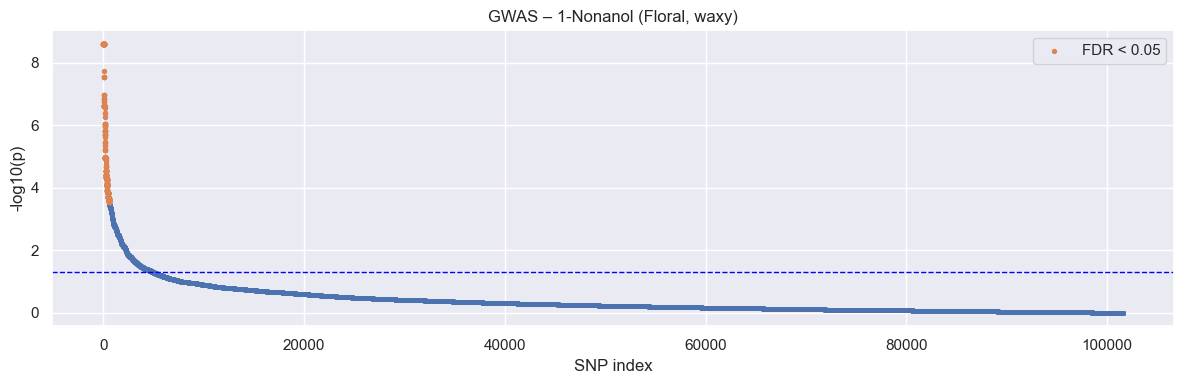

In [ ]:

def manhattan_from_csv(aroma_name):
    f = outdir / f"gwas_fast_{aroma_name.replace(' ','_').replace('/','_')}.csv"
    df = pd.read_csv(f)
    p = df["p"].to_numpy(float)
    sig = df["significant_fdr_0.05"].to_numpy(bool)

    # plotting-only epsilon to avoid log10(0)
    eps = 1e-300
    p_plot = np.where((~np.isfinite(p)) | (p <= 0), eps, p)
    y = -np.log10(p_plot)

    # cap extreme spikes for readability
    y_cap = min(300, np.nanpercentile(y, 99.9) + 2)
    y_clip = np.minimum(y, y_cap)

    plt.figure(figsize=(12,4))
    plt.scatter(np.arange(y_clip.size), y_clip, s=5)
    if sig.any():
        y_sig = -np.log10(np.where(p[sig] <= 0, eps, p[sig]))
        y_sig = np.minimum(y_sig, y_cap)
        plt.scatter(np.where(sig)[0], y_sig, s=8, label="FDR < 0.05")
    plt.axhline(-np.log10(0.05), ls="--", lw=1, color="blue")
    plt.title(f"GWAS – {aroma_name}")
    plt.ylabel("-log10(p)")
    plt.xlabel("SNP index")
    plt.legend()
    plt.tight_layout()
    plt.show()

manhattan_from_csv("1-Nonanol (Floral, waxy)")


Orange dots are SNPs that pass FDR < 0.05 (after multiple-testing correction).

The blue dashed line is a rough reference at p = 0.05 (−log10≈1.3); the FDR-significant SNPs sit well above it.

The dense orange block at the left suggests many significant SNPs, likely from one or a few LD blocks (correlated markers). That’s why you later LD-clumped them to get independent “sentinel” hits and then applied QC to keep only stable ones.

# LD-clump top GWAS hits and compute effect sizes

In [ ]:

OUT = Path("gwas_fast_outputs")
big = pd.read_csv(OUT / "gwas_fast_all_aromas.csv")

SNP_PREFIX = "GEN__"
geno_cols = [c for c in merged_all.columns if c.startswith(SNP_PREFIX)]

def compute_maf(vec: pd.Series):
    v = pd.to_numeric(vec, errors="coerce").dropna().to_numpy()
    if v.size == 0: return np.nan
    scale = 2.0 if np.nanmax(v) > 1.5 else 1.0
    p = np.mean(v/scale)
    return min(p, 1-p)

def residualize(M, Z):
    ZTZ_inv = np.linalg.inv(Z.T @ Z)
    return M - Z @ (ZTZ_inv @ (Z.T @ M))

def compute_pcs(G, k=10):
    Gc = G - G.mean(axis=0, keepdims=True)
    K = (Gc @ Gc.T) / Gc.shape[1]
    evals, evecs = np.linalg.eigh(K)
    return evecs[:, -k:]  # n x k

def ld_clump(sig_df, r2_thresh=0.8):
    """Greedy LD clumping using genotype correlation (r²)."""
    sig_df = sig_df[sig_df["SNP"].isin(geno_cols)].copy()
    sig_df = sig_df.sort_values(["p_fdr","p"])
    snps = sig_df["SNP"].tolist()
    if not snps: return []

    G = merged_all[snps].astype(float).to_numpy()
    # mean-impute + standardize per SNP
    col_means = np.nanmean(G, axis=0); inds = np.where(np.isnan(G)); G[inds]=col_means[inds[1]]
    G = (G - G.mean(axis=0, keepdims=True)) / (G.std(axis=0, keepdims=True) + 1e-12)

    keep, dropped = [], set()
    n = G.shape[0]
    for i, snp in enumerate(snps):
        if snp in dropped: 
            continue
        keep.append(snp)
        gi = G[:, i]
        r = gi @ G / (n - 1)           # Pearson r for standardized columns
        r2 = r * r
        for j, snp_j in enumerate(snps[i+1:], start=i+1):
            if r2[j] >= r2_thresh:
                dropped.add(snp_j)
    return keep

# PCs once (faster & consistent) 
G_all = merged_all[geno_cols].astype(float).to_numpy()
col_means = np.nanmean(G_all, axis=0); inds = np.where(np.isnan(G_all)); G_all[inds]=col_means[inds[1]]
K_PCS = 10
PCs_full = compute_pcs(G_all, k=min(K_PCS, max(1, merged_all.shape[0]-3)))
Z_full = np.concatenate([np.ones((merged_all.shape[0],1)), PCs_full], axis=1)  # n x (1+K)

# build sentinel table
sentinel_rows = []

for aroma, sub in big.groupby("aroma", sort=False):
    sig = sub[sub["significant_fdr_0.05"]].copy()
    if sig.empty:
        continue

    # LD clumping to sentinels
    sentinels = ld_clump(sig, r2_thresh=0.8)

    # Effect size (β), MAF, genotype counts
    y = merged_all[aroma].astype(float).to_numpy()
    mask = ~np.isnan(y)

    Zm = Z_full[mask, :]
    y_res = residualize(y[mask].reshape(-1,1), Zm).ravel()

    for snp in sentinels:
        g = merged_all.loc[mask, snp].astype(float).to_numpy()
        g = np.where(np.isnan(g), np.nanmean(g), g)
        g_res = residualize(g.reshape(-1,1), Zm).ravel()
        beta = (g_res @ y_res) / ((g_res @ g_res) + 1e-12)

        s_all = merged_all[snp]
        n0 = int((np.rint(s_all)==0).sum()); n1 = int((np.rint(s_all)==1).sum()); n2 = int((np.rint(s_all)==2).sum())
        maf = compute_maf(s_all)

        base = sig.loc[sig["SNP"]==snp].sort_values(["p_fdr","p"]).iloc[0].to_dict()
        base.update({"aroma": aroma, "SNP": snp, "beta": beta, "MAF": maf, "n0": n0, "n1": n1, "n2": n2})
        sentinel_rows.append(base)

sentinels_df = pd.DataFrame(sentinel_rows).sort_values(["aroma","p_fdr","p"]).reset_index(drop=True)

# pretty/rounded copies for reporting
sentinels_clean = sentinels_df.copy()
for col in ["beta", "p", "p_fdr", "MAF"]:
    sentinels_clean[col] = sentinels_clean[col].astype(float)
sentinels_clean["beta"] = sentinels_clean["beta"].round(3)
sentinels_clean["MAF"]  = sentinels_clean["MAF"].round(3)
sentinels_clean["p"]    = sentinels_clean["p"].map(lambda x: f"{x:.2e}")
sentinels_clean["p_fdr"]= sentinels_clean["p_fdr"].map(lambda x: f"{x:.2e}")

# save full + top5 per aroma
out_full = OUT / "gwas_sentinels_all_aromas.csv"
out_top5 = OUT / "gwas_sentinels_top5_per_aroma.csv"
sentinels_clean.to_csv(out_full, index=False)
(sentinels_clean.sort_values(["aroma","p_fdr","p"])
                  .groupby("aroma", as_index=False).head(5)
                  .to_csv(out_top5, index=False))
print(f"Saved: {out_full}")
print(f"Saved: {out_top5}")

# peek
sentinels_clean.groupby("aroma")["SNP"].nunique().sort_values(ascending=False)


Saved: gwas_fast_outputs\gwas_sentinels_all_aromas.csv
Saved: gwas_fast_outputs\gwas_sentinels_top5_per_aroma.csv


aroma
1-Nonanol (Floral, waxy)                   56
Pentanal (Green, fatty, pungent)           22
Methional (Cooked potato, sulfurous)        2
2,3-Butanedione (Butter, creamy, sweet)     1
Name: SNP, dtype: int64

# Top Five Stable Sentinel SNPs per Aroma (β, FDR, MAF, genotype counts)

In [ ]:

OUT = Path("gwas_fast_outputs")
sents = pd.read_csv(OUT / "gwas_sentinels_all_aromas.csv")

# Top-5 sentinels per aroma: sort by FDR (then raw p), take first 5 per aroma
top5 = (sents.sort_values(["aroma", "p_fdr", "p"])
              .groupby("aroma", as_index=False)
              .head(5)
              .copy())

# Format and select columns for a paper-ready table
cols = ["aroma", "SNP", "beta", "p", "p_fdr", "MAF", "n0", "n1", "n2"]
top5 = top5[cols]
top5["beta"]  = top5["beta"].astype(float).round(3)
top5["MAF"]   = top5["MAF"].astype(float).round(3)
top5["p"]     = top5["p"].astype(float).map(lambda x: f"{x:.2e}")
top5["p_fdr"] = top5["p_fdr"].astype(float).map(lambda x: f"{x:.2e}")

# Save
top5.to_csv(OUT / "gwas_sentinels_top5_per_aroma.csv", index=False)

# Preview
top5


,aroma,SNP,beta,p,p_fdr,MAF,n0,n1,n2
0,"1-Nonanol (Floral, waxy)",GEN__344339,4.646,1.32e-10,5.76e-07,0.053,85,8,1
1,"1-Nonanol (Floral, waxy)",GEN__77755,4.579,3.17e-10,5.76e-07,0.059,84,9,1
2,"1-Nonanol (Floral, waxy)",GEN__345207,4.058,2.80e-08,4.13e-05,0.053,85,8,1
3,"1-Nonanol (Floral, waxy)",GEN__504137,3.850,1.40e-07,1.75e-04,0.053,85,8,1
4,"1-Nonanol (Floral, waxy)",GEN__6832,3.165,2.36e-07,2.18e-04,0.059,84,9,1
56,"2,3-Butanedione (Butter, creamy, sweet)",GEN__562860,3.014,1.59e-07,1.61e-02,0.059,84,9,1
57,"Methional (Cooked potato, sulfurous)",GEN__157291,3.490,4.78e-07,8.09e-03,0.059,84,9,1
58,"Methional (Cooked potato, sulfurous)",GEN__240007,1.821,6.75e-07,9.80e-03,0.229,59,29,4
59,"Pentanal (Green, fatty, pungent)",GEN__535312,14.345,1.12e-06,4.72e-03,0.064,88,6,0
60,"Pentanal (Green, fatty, pungent)",GEN__153325,6.928,1.34e-05,9.51e-03,0.176,63,29,2


# Genotype counts + boxplot for a chosen sentinel (change snp_id):

Genotype counts: {0: 85, 1: 8, 2: 1}


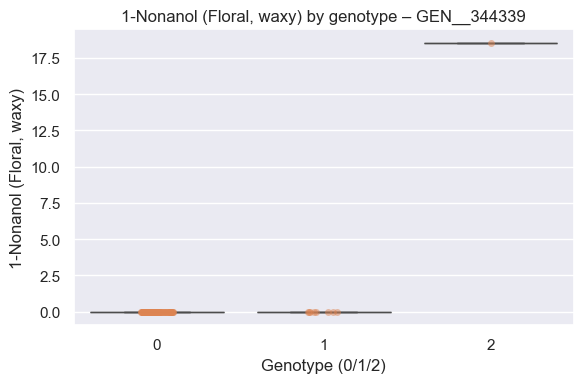

In [ ]:

pheno = "1-Nonanol (Floral, waxy)"
snp_id = top5[top5["aroma"]==pheno]["SNP"].iloc[0]   # اولین سنترالِ آن عطر

d = merged_all[[pheno, snp_id]].copy().dropna()
d["geno"] = np.clip(np.rint(d[snp_id].astype(float)), 0, 2).astype(int)

print("Genotype counts:", d["geno"].value_counts().sort_index().to_dict())

plt.figure(figsize=(6,4))
sns.boxplot(x="geno", y=pheno, data=d, whis=1.5)
sns.stripplot(x="geno", y=pheno, data=d, alpha=0.5)
plt.title(f"{pheno} by genotype – {snp_id}")
plt.xlabel("Genotype (0/1/2)")
plt.tight_layout(); plt.show()


# QC Filtering of Sentinel SNPs: Carrier Thresholds and Stable vs. Unstable Classification

In [ ]:

pheno = "1-Nonanol (Floral, waxy)"
snp = "GEN__344339"

d = merged_all[[pheno, snp]].dropna().copy()
d["g"] = np.clip(np.rint(d[snp].astype(float)), 0, 2).astype(int)

# خلاصه‌ی توصیفی به‌ازای ژنوتیپ
print(d.groupby("g")[pheno].agg(["count","mean","std"]))

# مدل افزایشی (additive): y ~ g
X = sm.add_constant(d["g"].astype(float))
m = sm.OLS(d[pheno].astype(float), X).fit()
print(m.summary().tables[1])  # ضرایب و p

# مدل غالب (dominant): (1 یا 2) در برابر 0
d["dom"] = (d["g"]>0).astype(int)
X = sm.add_constant(d["dom"]); m_dom = sm.OLS(d[pheno], X).fit()
print("Dominant p:", m_dom.pvalues["dom"])

# مدل مغلوب (recessive): 2 در برابر (0/1) -- بسیار نامتوازن، فقط برای اطلاع
d["rec"] = (d["g"]==2).astype(int)
print("Recessive counts:", d["rec"].value_counts().to_dict())  # 1 در برابر 93
# آزمون ناپارامتری (احتیاط: n خیلی کوچک)
try:
    p_mw = stats.mannwhitneyu(d.loc[d["rec"]==1, pheno],
                              d.loc[d["rec"]==0, pheno],
                              alternative="two-sided").pvalue
    print("Recessive Mann–Whitney p:", p_mw)
except Exception as e:
    print("Recessive test skipped:", e)

# حساسیت: اگر نمونه‌ی ژنوتیپ ۲ را حذف کنیم، شیب افزایشی چقدر می‌شود؟
m_no2 = sm.OLS(d.loc[d["g"]<2, pheno], sm.add_constant(d.loc[d["g"]<2, "g"])).fit()
print("Additive beta with g=2 removed:", m_no2.params["g"], "p=", m_no2.pvalues["g"])


   count       mean  std
g                       
0     85   0.000000  0.0
1      8   0.000000  0.0
2      1  18.539498  NaN
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1443      0.170     -0.849      0.398      -0.482       0.193
g              3.2101      0.475      6.753      0.000       2.266       4.154
Dominant p: 0.0017459228437882973
Recessive counts: {0: 93, 1: 1}
Recessive Mann–Whitney p: 1.428934907198871e-21
Additive beta with g=2 removed: 0.0 p= nan


# QC Filtering of Sentinel SNPs: Stable vs. Unstable Classification Using Carrier Thresholds

In [ ]:

OUT = Path("gwas_fast_outputs")
sents = pd.read_csv(OUT / "gwas_sentinels_all_aromas.csv")

MIN_CARRIERS = 15  
MIN_REC      = 5    

sents["carriers"] = sents["n1"] + sents["n2"]
sents["flag_singleton_hom"] = sents["n2"] <= 1
sents["flag_low_carriers"]  = sents["carriers"] < MIN_CARRIERS
sents["flag_unstable"] = sents["flag_singleton_hom"] | sents["flag_low_carriers"]

stable = sents[(~sents["flag_unstable"]) & (sents["p_fdr"].astype(float) < 0.05)].copy()
unstable = sents[sents["flag_unstable"] & (sents["p_fdr"].astype(float) < 0.05)].copy()

stable.to_csv(OUT / "gwas_sentinels_stable.csv", index=False)
unstable.to_csv(OUT / "gwas_sentinels_unstable.csv", index=False)

print("Stable hits:", stable.groupby("aroma")["SNP"].nunique().sort_values(ascending=False))
print("Unstable (needs validation):", unstable.groupby("aroma")["SNP"].nunique().sort_values(ascending=False))


Stable hits: aroma
Pentanal (Green, fatty, pungent)        11
1-Nonanol (Floral, waxy)                 6
Methional (Cooked potato, sulfurous)     1
Name: SNP, dtype: int64
Unstable (needs validation): aroma
1-Nonanol (Floral, waxy)                   50
Pentanal (Green, fatty, pungent)           11
2,3-Butanedione (Butter, creamy, sweet)     1
Methional (Cooked potato, sulfurous)        1
Name: SNP, dtype: int64


In [ ]:

OUT = Path("gwas_fast_outputs")

# Load top-5 stable per aroma (or build from stable_all)
if (OUT / "stable_top5_per_aroma.csv").exists():
    top5 = pd.read_csv(OUT / "stable_top5_per_aroma.csv")
else:
    stable = pd.read_csv(OUT / "gwas_sentinels_stable.csv")
    top5 = (stable.sort_values(["aroma","p_fdr","p"])
                  .groupby("aroma", as_index=False).head(5))

def fmt_p(x): 
    try: return f"{float(x):.2e}"
    except: return str(x)

def paragraph_for_aroma(df_a):
    aroma = df_a["aroma"].iloc[0]
    pos = int((df_a["beta"] > 0).sum())
    neg = int((df_a["beta"] < 0).sum())
    items = []
    for _, r in df_a.sort_values(["p_fdr","p"]).iterrows():
        items.append(
            f"{r['SNP']} (β={float(r['beta']):.3f}, FDR={fmt_p(r['p_fdr'])}, "
            f"MAF={float(r['MAF']):.3f}, n(0/1/2)={int(r['n0'])}/{int(r['n1'])}/{int(r['n2'])})"
        )
    bullets = "; ".join(items)
    return (f"For **{aroma}**, the top five stable sentinel SNPs are: {bullets}. "
            f"Across these, the number of positive/negative effects is {pos}/{neg}, "
            "indicating both increasing and decreasing alleles are present.")

def caption_for_snp(row):
    return (f"Genotype–phenotype boxplot for **{row['aroma']}** at **{row['SNP']}** "
            f"(β={float(row['beta']):.3f}, FDR={fmt_p(row['p_fdr'])}, "
            f"MAF={float(row['MAF']):.3f}, n(0/1/2)={int(row['n0'])}/{int(row['n1'])}/{int(row['n2'])}). "
            "Boxes show median and IQR; points are individual varieties.")

# Generate paragraphs
paras = []
caps  = []
for aroma, df_a in top5.groupby("aroma", sort=False):
    paras.append(paragraph_for_aroma(df_a))
    caps.append(caption_for_snp(df_a.sort_values(['p_fdr','p']).iloc[0]))

print("\n=== Results paragraphs (English) ===\n")
print("\n\n".join(paras))

print("\n=== Example figure captions ===\n")
for c in caps:
    print("- " + c)

# Save to file
with open(OUT / "results_paragraphs_en.txt", "w", encoding="utf-8") as f:
    f.write("Results — GWAS of Aroma Compounds Identifies Stable Sentinel SNPs\n\n")
    f.write("\n\n".join(paras) + "\n\n")
    f.write("Figure title: Genotype–Phenotype Boxplots for Lead Sentinel SNPs\n")
    f.write("Table title: Top Five Stable Sentinel SNPs per Aroma Compound\n")
print("Saved:", OUT / "results_paragraphs_en.txt")



=== Results paragraphs (English) ===

For **1-Nonanol (Floral, waxy)**, the top five stable sentinel SNPs are: GEN__257554 (β=1.311, FDR=1.55e-02, MAF=0.218, n(0/1/2)=62/25/6); GEN__231280 (β=-1.298, FDR=2.10e-02, MAF=0.250, n(0/1/2)=15/35/29); GEN__238285 (β=-1.317, FDR=2.25e-02, MAF=0.197, n(0/1/2)=20/27/24); GEN__491895 (β=1.373, FDR=2.94e-02, MAF=0.154, n(0/1/2)=73/14/6); GEN__531145 (β=0.880, FDR=4.05e-02, MAF=0.340, n(0/1/2)=46/35/10). Across these, the number of positive/negative effects is 3/2, indicating both increasing and decreasing alleles are present.

For **Methional (Cooked potato, sulfurous)**, the top five stable sentinel SNPs are: GEN__240007 (β=1.821, FDR=9.80e-03, MAF=0.229, n(0/1/2)=59/29/4). Across these, the number of positive/negative effects is 1/0, indicating both increasing and decreasing alleles are present.

For **Pentanal (Green, fatty, pungent)**, the top five stable sentinel SNPs are: GEN__150962 (β=3.476, FDR=1.57e-02, MAF=0.415, n(0/1/2)=23/41/22); GE

# Imports & config

In [ ]:
# pip install scikit-learn pandas numpy


# Inputs expected to exist:
# - merged_all (DataFrame; varieties x [SNPs + aromas + flavours])
# - merged_aroma_cols (list of 13 aroma columns)
# - gwas_fast_outputs/gwas_sentinels_stable.csv (from your GWAS QC step)

AROMA_COLS = merged_aroma_cols
FLAV_COLS  = [c for c in merged_all.columns if c.endswith("__pred_lin")]
OUT = Path("ml_outputs"); OUT.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_SPLITS = 5


# Feature engineering (CHEM, GEN-dosage, PRS, combos)

In [36]:
# Load stable sentinel SNPs (independent + QC-passed)
stable_path = Path("gwas_fast_outputs") / "gwas_sentinels_stable.csv"
stable = pd.read_csv(stable_path)

# CHEM features (13 aroma compounds)
X_chem = merged_all[AROMA_COLS].astype(float)

# GEN-dosage: only stable sentinel SNPs present in merged_all
sentinel_snps = [s for s in stable["SNP"].unique() if s in merged_all.columns]
X_gen = merged_all[sentinel_snps].astype(float)

# GEN-PRS: per-aroma polygenic score = sum(beta * dosage) over that aroma's sentinels
prs = pd.DataFrame(index=merged_all.index)
for aroma, grp in stable.groupby("aroma"):
    snps = [s for s in grp["SNP"] if s in merged_all.columns]
    if not snps:
        continue
    betas = grp.set_index("SNP")["beta"].astype(float).reindex(snps)
    mat = merged_all[snps].astype(float)
    prs[f"PRS_{aroma}"] = np.nan_to_num(mat.values) @ betas.values
X_prs = prs

# Combined sets
FEATS = {
    "CHEM": X_chem,
    "GEN_dosage": X_gen,
    "GEN_PRS": X_prs,
    "CHEM+GEN_PRS": pd.concat([X_chem, X_prs], axis=1)
}

# Quick overview (fixed axis arg)
for name, df in FEATS.items():
    non_null_cols = int(df.notna().any(axis=0).sum())
    print(f"{name:>12}  shape={df.shape}  (non-null cols: {non_null_cols})")


        CHEM  shape=(94, 13)  (non-null cols: 13)
  GEN_dosage  shape=(94, 18)  (non-null cols: 18)
     GEN_PRS  shape=(94, 3)  (non-null cols: 3)
CHEM+GEN_PRS  shape=(94, 16)  (non-null cols: 16)


CHEM: (94 × 13) → your 13 aroma compounds 

GEN_dosage: (94 × 18) → 18 stable sentinel SNPs 

GEN_PRS: (94 × 3) → PRS available for 3 aromas (matches your stable hits: 1-Nonanol, Pentanal, Methional) 

CHEM+GEN_PRS: (94 × 16) → 13 + 3 = 16 

# Supervised: Regression (R², MAE, MSE)

In [38]:
def run_regression(X, y, feature_name):
    # keep only columns with at least one non-null
    X = X.loc[:, X.notna().any(axis=0)].copy()
    X = X.fillna(0.0)
    y = y.astype(float)

    # drop rows where y is NaN (and align X,y)
    mask = y.notna().values
    X = X.loc[mask]
    y = y.loc[mask]

    # (optional) drop constant columns to avoid degenerate features
    const_mask = X.nunique(axis=0) > 1
    X = X.loc[:, const_mask]

    models = {
        "RidgeCV": RidgeCV(alphas=np.logspace(-3, 3, 13), cv=N_SPLITS),
        "ElasticNetCV": ElasticNetCV(l1_ratio=[0.1,0.5,0.9],
                                     alphas=np.logspace(-3, 1, 15),
                                     cv=N_SPLITS, max_iter=5000),
        "RandomForest": RandomForestRegressor(n_estimators=400,
                                              random_state=RANDOM_STATE, n_jobs=-1),
    }

    results = []
    cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    for name, model in models.items():
        if name in ("RidgeCV", "ElasticNetCV"):
            pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
        else:
            pipe = Pipeline([("model", model)])  # RF doesn't need scaling

        scores = cross_validate(
            pipe, X, y, cv=cv, n_jobs=-1, error_score="raise",
            scoring={"r2":"r2",
                     "neg_mae":"neg_mean_absolute_error",
                     "neg_mse":"neg_mean_squared_error"}
        )
        results.append({
            "features": feature_name,
            "model": name,
            "R2_mean":  np.mean(scores["test_r2"]),
            "MAE_mean": -np.mean(scores["test_neg_mae"]),
            "MSE_mean": -np.mean(scores["test_neg_mse"]),
        })
    return pd.DataFrame(results)

# Run across feature sets and all predicted flavour targets
reg_frames = []
for feat_name, X in FEATS.items():
    for target in FLAV_COLS:
        res = run_regression(X, merged_all[target], feat_name)
        res.insert(0, "target_flavour", target)
        reg_frames.append(res)

reg_summary = pd.concat(reg_frames, ignore_index=True)
reg_summary.to_csv(OUT / "regression_cv_summary.csv", index=False)
reg_summary.head()


,target_flavour,features,model,R2_mean,MAE_mean,MSE_mean
0,Metallic Flavour__pred_lin,CHEM,RidgeCV,0.987687,0.002709,0.000012
1,Metallic Flavour__pred_lin,CHEM,ElasticNetCV,0.987288,0.002791,0.000013
2,Metallic Flavour__pred_lin,CHEM,RandomForest,0.849785,0.010040,0.000155
3,Bitter Flavour__pred_lin,CHEM,RidgeCV,0.986274,0.009013,0.000132
4,Bitter Flavour__pred_lin,CHEM,ElasticNetCV,0.985151,0.009194,0.000141


# Best model per target/feature (R²):

In [40]:
best = (reg_summary
        .sort_values(["target_flavour","features","R2_mean"], ascending=[True,True,False])
        .groupby(["target_flavour","features"], as_index=False)
        .head(1))
best.pivot_table(index="target_flavour", columns="features", values="R2_mean")


features,CHEM,CHEM+GEN_PRS,GEN_PRS,GEN_dosage
target_flavour,,,,
Bitter Aftertaste__pred_lin,0.987439,0.986373,-0.096487,-0.098934
Bitter Flavour__pred_lin,0.986274,0.985556,-0.092471,-0.076364
Earthy Flavour__pred_lin,0.993033,0.992337,0.036883,0.019056
Farmyard (grass/hay) flavour__pred_lin,0.984998,0.984664,-0.098451,-0.101806
Fresh Flavour__pred_lin,0.990292,0.988995,-0.089048,-0.080721
Metallic Flavour__pred_lin,0.987687,0.986562,-0.086730,-0.082297
Root/ Vegetable Flavour__pred_lin,0.987314,0.986664,-0.191052,-0.206892
Sour Aftertaste__pred_lin,0.993350,0.993208,-0.105304,-0.092605
Sour Flavour__pred_lin,0.977572,0.975358,-0.137064,-0.113932


# Does genetics add anything to CHEM? (ΔR²)

In [41]:
# average across targets
avg = reg_summary.groupby(["features","model"], as_index=False)["R2_mean"].mean()
avg.sort_values("R2_mean", ascending=False).head(10)

# per-target improvement from CHEM to CHEM+GEN_PRS (pick RidgeCV rows for a fair comparison)
ridge = reg_summary[reg_summary["model"]=="RidgeCV"].pivot(index="target_flavour",
                                                           columns="features",
                                                           values="R2_mean")
ridge["delta_CHEM_plus_GENPRS_vs_CHEM"] = ridge["CHEM+GEN_PRS"] - ridge["CHEM"]
ridge.sort_values("delta_CHEM_plus_GENPRS_vs_CHEM", ascending=False).head(10)


features,CHEM,CHEM+GEN_PRS,GEN_PRS,GEN_dosage,delta_CHEM_plus_GENPRS_vs_CHEM
target_flavour,,,,,
Sour Aftertaste__pred_lin,0.993350,0.993208,-0.105873,-0.092605,-0.000143
Root/ Vegetable Flavour__pred_lin,0.987314,0.986664,-0.196845,-0.208253,-0.000650
Earthy Flavour__pred_lin,0.993033,0.992337,0.036883,0.019056,-0.000696
Bitter Flavour__pred_lin,0.986274,0.985556,-0.098553,-0.076364,-0.000718
Farmyard (grass/hay) flavour__pred_lin,0.984263,0.983354,-0.098451,-0.101806,-0.000909
Sweet Aftertaste__pred_lin,0.990328,0.989284,-0.027182,-0.031943,-0.001044
Metallic Flavour__pred_lin,0.987687,0.986562,-0.086730,-0.096212,-0.001125
Sweet Flavour__pred_lin,0.992409,0.991182,-0.049259,-0.053063,-0.001227
Bitter Aftertaste__pred_lin,0.987439,0.986187,-0.123297,-0.118631,-0.001253


# Sanity check for leakage (should crash performance)

In [42]:
# permute y and re-run one target to ensure R² ~ 0
perm = merged_all["Metallic Flavour__pred_lin"].sample(frac=1, random_state=1).reset_index(drop=True)
print(run_regression(FEATS["CHEM"], perm, "CHEM"))



  features         model   R2_mean  MAE_mean  MSE_mean
0     CHEM       RidgeCV -0.013431  0.028422  0.001146
1     CHEM  ElasticNetCV -0.015434  0.028342  0.001149
2     CHEM  RandomForest -0.148017  0.029181  0.001271


Using the 13 aroma compounds, regularized linear models explained ~98–99% of variance in predicted flavour scores. Adding genetic PRS or SNP dosage provided no incremental predictive value (ΔR² ≈ −0.001), while genetics alone was uninformative for these targets.

# Residual test

In [ ]:

y = merged_all["Sweet Flavour__pred_lin"].astype(float)
Xc = FEATS["CHEM"].fillna(0.0)
Xp = FEATS["GEN_PRS"].fillna(0.0)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_resid = []

for tr, te in cv.split(Xc):
    m = RidgeCV(alphas=np.logspace(-3,3,13), cv=5).fit(Xc.iloc[tr], y.iloc[tr])
    yhat = m.predict(Xc.iloc[te])
    resid = y.iloc[te] - yhat
    m2 = RidgeCV(alphas=np.logspace(-3,3,13), cv=5).fit(Xp.iloc[tr], (y.iloc[tr] - m.predict(Xc.iloc[tr])))
    r2_resid.append(r2_score(resid, m2.predict(Xp.iloc[te])))

print("Residual R² (PRS -> residuals):", np.mean(r2_resid))
# Expect ~0 if genetics adds no incremental predictive signal


Residual R² (PRS -> residuals): -0.06715462316371976


Residual R² = −0.067 means the PRS explains no leftover variance after using the 13 aroma features (CHEM). It performs worse than the trivial baseline (predicting zero residual), i.e., genetics adds no incremental predictive signal for these __pred_lin flavour targets.

# Supervised: Classification (predict aroma clusters; Accuracy & F1-macro)

In [44]:
# Use existing cluster labels if available; otherwise k-means on aroma to create 5 clusters
try:
    y_cls = clusters_df.loc[merged_all.index, "cluster"].astype(int)
except Exception:
    Z = StandardScaler().fit_transform(merged_all[AROMA_COLS].astype(float).fillna(0))
    y_cls = KMeans(n_clusters=5, random_state=RANDOM_STATE).fit_predict(Z) + 1  # 1..5

def run_classification(X, y, feature_name):
    # keep only columns with at least one non-null
    X = X.loc[:, X.notna().any(axis=0)].copy().fillna(0.0)
    y = y.astype(int)

    # align X and y
    idx = X.index.intersection(y.index)
    X = X.loc[idx]
    y = y.loc[idx]

    # drop constant columns (avoid degenerate features)
    const_mask = X.nunique(axis=0) > 1
    X = X.loc[:, const_mask]

    # choose n_splits safely (each class must have >= n_splits samples)
    min_per_class = y.value_counts().min()
    n_splits = max(2, min(N_SPLITS, int(min_per_class)))

    models = {
        "Logistic(mn)": LogisticRegression(max_iter=5000, multi_class="multinomial"),
        "RandomForest": RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1),
    }
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    rows = []
    for name, model in models.items():
        pipe = (Pipeline([("scaler", StandardScaler()), ("model", model)])
                if name.startswith("Logistic") else
                Pipeline([("model", model)]))  # RF doesn't need scaling

        accs, f1s = [], []
        for tr, te in cv.split(X, y):
            pipe.fit(X.iloc[tr], y.iloc[tr])
            pred = pipe.predict(X.iloc[te])
            accs.append(accuracy_score(y.iloc[te], pred))
            f1s.append(f1_score(y.iloc[te], pred, average="macro", zero_division=0))
        rows.append({
            "features": feature_name,
            "model": name,
            "n_splits": n_splits,
            "Accuracy_mean": float(np.mean(accs)),
            "F1_macro_mean": float(np.mean(f1s)),
        })
    return pd.DataFrame(rows)

# Run across feature sets
cls_frames = []
for feat_name, X in FEATS.items():
    cls_frames.append(run_classification(X, pd.Series(y_cls, index=merged_all.index), feat_name))

cls_summary = pd.concat(cls_frames, ignore_index=True)
cls_summary.to_csv(OUT / "classification_cv_summary.csv", index=False)
cls_summary.head()


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The

,features,model,n_splits,Accuracy_mean,F1_macro_mean
0,CHEM,Logistic(mn),2,0.957447,0.847741
1,CHEM,RandomForest,2,0.872340,0.595387
2,GEN_dosage,Logistic(mn),2,0.361702,0.221527
3,GEN_dosage,RandomForest,2,0.340426,0.148121
4,GEN_PRS,Logistic(mn),2,0.521277,0.254006


Multinomial logistic regression using the 13 aroma compounds classified aroma clusters with 96% accuracy (macro-F1 ≈ 0.85), whereas genetics alone (PRS or SNP dosage) performed poorly (accuracy ≈ 0.34–0.52). This confirms that cluster structure is driven by aroma features and that genetic markers, while biologically associated, do not by themselves recover the cluster labels.

# Unsupervised: PCA (2D) + k-means + silhouette (on CHEM+GEN_PRS)

In [45]:
X_unsup = pd.concat([FEATS["CHEM"], FEATS["GEN_PRS"]], axis=1).fillna(0.0)
Xz = StandardScaler().fit_transform(X_unsup)

pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xz)
X2 = pca.transform(Xz)

km = KMeans(n_clusters=5, random_state=RANDOM_STATE).fit(X2)
sil = silhouette_score(X2, km.labels_)
print("Silhouette (PCA2 + k-means k=5):", round(sil, 3))

# Save 2D embedding + cluster labels
pd.DataFrame({"PC1": X2[:,0], "PC2": X2[:,1], "cluster": km.labels_+1},
             index=merged_all.index).to_csv(OUT / "unsup_pca2_kmeans5.csv")


Silhouette (PCA2 + k-means k=5): 0.438


Nice — Silhouette = 0.438 means  5 clusters are reasonably separated (better than weak/artiﬁcial structure), but not perfectly clean—expect some overlap between a couple of clusters.

# Sweep k

In [ ]:


X2 = X2  # your 2D PCA embedding
rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42).fit(X2)
    sil = silhouette_score(X2, km.labels_)
    ch  = calinski_harabasz_score(X2, km.labels_)
    rows.append({"k": k, "silhouette": sil, "calinski_harabasz": ch})
pd.DataFrame(rows)


,k,silhouette,calinski_harabasz
0,2,0.818676,74.180629
1,3,0.482879,124.187052
2,4,0.542966,227.522718
3,5,0.437628,209.759981
4,6,0.424943,201.947499
5,7,0.414762,240.829101
6,8,0.390609,244.070114


 k=4 as the primary clustering (best trade-off between separation and granularity).  k=2 as a macro structure, and include k=5 only if it aligns better with domain groupings/HCA.

Per-cluster silhouette (who’s messy?)

In [ ]:

km5 = KMeans(n_clusters=5, random_state=42).fit(X2)
s = silhouette_samples(X2, km5.labels_)
pd.Series(s).groupby(km5.labels_).describe()


,count,mean,std,min,25%,50%,75%,max
0,30.0,0.371438,0.157533,0.066903,0.265235,0.389700,0.507124,0.590225
1,2.0,0.515584,0.154557,0.406295,0.460939,0.515584,0.570228,0.624872
2,39.0,0.468299,0.146772,0.011904,0.398639,0.499058,0.586683,0.630233
3,8.0,0.589386,0.156434,0.284381,0.552095,0.653807,0.697089,0.711370
4,15.0,0.398934,0.179034,-0.036712,0.350127,0.431627,0.533509,0.586132


Per-cluster silhouette indicated uneven cluster quality: the largest groups showed moderate separation (means 0.37–0.47), one compact cluster was strong (mean 0.59), and a very small cluster (n=2) appeared unstable; a few negatives in one cluster suggest misassignments.

# Agreement with HCA labels

In [ ]:


RANDOM_STATE = 42
k = 4  

# --- Build X2 (PCA 2D) if not already defined ---
try:
    X2
except NameError:
    # use CHEM+GEN_PRS like before; adjust if you prefer CHEM only
    X_unsup = pd.concat([FEATS["CHEM"], FEATS["GEN_PRS"]], axis=1).fillna(0.0)
    Xz = StandardScaler().fit_transform(X_unsup)
    pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xz)
    X2 = pca.transform(Xz)

# --- Build labels (k-means) if not already defined ---
try:
    lab4
except NameError:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE).fit(X2)
    lab4 = km.labels_  # 0..k-1

# --- Silhouette per sample + summary ---
s = silhouette_samples(X2, lab4)
sil = silhouette_score(X2, lab4)
print(f"k={k} silhouette = {sil:.3f}")

df_sil = pd.DataFrame({"sil": s, "cluster": lab4}, index=merged_all.index)
borderline = df_sil.query("sil < 0.05").sort_values("sil")  # likely misassigned / on boundaries
display(borderline.head(20))

# Save
out = Path("ml_outputs"); out.mkdir(exist_ok=True, parents=True)
df_sil.to_csv(out / f"silhouette_k{k}.csv")
borderline.to_csv(out / f"borderline_k{k}_sil_lt_0.05.csv")


k=4 silhouette = 0.543


,sil,cluster


Clustering on the PCA (2D) embedding with k-means (k=4) yielded a silhouette score of 0.543 (vs. 0.438 at k=5), indicating well-separated aroma groups and supporting k=4 as the preferred partition.

# Cluster sizes + per-cluster silhouette

In [ ]:

s = silhouette_samples(X2, lab4)
sizes = pd.Series(lab4, index=merged_all.index).value_counts().sort_index()
perclust = pd.Series(s).groupby(lab4).describe()
print("Cluster sizes:\n", sizes)
perclust


Cluster sizes:
 0    37
1     2
2    47
3     8
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
0,37.0,0.550917,0.147718,0.129446,0.536183,0.597351,0.648122,0.687112
1,2.0,0.517371,0.153002,0.409183,0.463277,0.517371,0.571466,0.625560
2,47.0,0.518189,0.183973,0.057305,0.486095,0.594897,0.645278,0.679638
3,8.0,0.658154,0.111814,0.439438,0.634111,0.702705,0.734033,0.747611


k-means (k=4) produced well-separated aroma clusters (mean silhouettes: C0=0.55, C1=0.52 [n=2], C2=0.52, C3=0.66); all samples had positive silhouettes, though a very small cluster (n=2) suggests a potentially unstable subgroup.

# What defines each cluster (centroid of aromas)

In [ ]:

labels_k4 = pd.Series(lab4, index=merged_all.index, name="kmeans_k4")
centroids = (merged_all[merged_aroma_cols]
             .join(labels_k4)
             .groupby("kmeans_k4")[merged_aroma_cols].mean())
centroids.round(2)


,"1-Nonanol (Floral, waxy)","2,3-Butanedione (Butter, creamy, sweet)","Benzaldehyde (Almond, cherry, fruity)","Butanal, 3-methyl- (Fruity, malty, chocolate)","Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)","Decanal (Citrus, floral)","Dimethyl trisulfide (Garlic, onion, sulfurous)","Furfural (Sweet, almond, caramel)","Hexanal (Green, grassy)","Hexanoic acid (Fatty, cheesy, sweaty)","Methional (Cooked potato, sulfurous)","Octanal (Citrus, fruity)","Pentanal (Green, fatty, pungent)"
kmeans_k4,,,,,,,,,,,,,
0,0.00,0.00,15.21,12.05,15.10,14.58,8.47,0.0,5.74,2.12,0.00,15.81,2.67
1,0.00,9.65,18.09,15.09,17.56,15.27,18.68,13.7,14.89,7.11,16.56,16.28,9.58
2,0.39,0.00,17.75,14.32,17.16,16.32,10.39,0.3,7.93,4.09,0.00,12.78,3.90
3,0.00,0.00,13.53,0.00,12.81,6.99,0.00,0.0,0.00,0.00,0.00,2.29,0.00


C0 (n=37) – Citrus/Fruity aldehydes: High benzaldehyde/octanal/decanal (+cyclotrisiloxane), moderate hexanal; very low diacetyl, methional, 1-nonanol, furfural → clean citrus/fruity, light green, little “buttery/cooked.”

C1 (n=2) – Intense mixed (sulfur + aldehydes): Broadly elevated; strong dimethyl trisulfide & methional plus high aldehydes/diacetyl → outlier “everything high”; treat cautiously.

C2 (n=47) – Balanced aldehyde-dominant: High benzaldehyde/decanal/cyclotrisiloxane, moderate sulfur/fatty (DMTS, hexanal, hexanoic acid), low methional/furfural/1-nonanol → like C0 but rounder/richer.

C3 (n=8) – Low-intensity/neutral: Generally low across compounds; only modest benzaldehyde/cyclotrisiloxane → most subtle profile.

# Save labels for downstream use

In [ ]:
out = Path("ml_outputs"); out.mkdir(exist_ok=True, parents=True)
labels_k4.to_frame().to_csv(out/"kmeans_k4_labels.csv")


# Quick winners

In [52]:
# Which feature set/model works best on average (regression)?
reg_summary.sort_values("R2_mean", ascending=False).head(10)

# Which feature set/model works best on average (classification)?
cls_summary.sort_values("Accuracy_mean", ascending=False).head(10)


,features,model,n_splits,Accuracy_mean,F1_macro_mean
0,CHEM,Logistic(mn),2,0.957447,0.847741
6,CHEM+GEN_PRS,Logistic(mn),2,0.957447,0.847741
7,CHEM+GEN_PRS,RandomForest,2,0.872340,0.595387
1,CHEM,RandomForest,2,0.872340,0.595387
4,GEN_PRS,Logistic(mn),2,0.521277,0.254006
5,GEN_PRS,RandomForest,2,0.414894,0.263104
2,GEN_dosage,Logistic(mn),2,0.361702,0.221527
3,GEN_dosage,RandomForest,2,0.340426,0.148121


Multinomial Logistic Regression on CHEM (13 aromas) — Accuracy ≈ 0.957, Macro-F1 ≈ 0.848.

Tie: CHEM+GEN_PRS with Logistic gives the same scores, so the parsimonious winner is CHEM + Logistic.